# Neural network architectures against classical benchmarks

Two reserving architectures are compared here against classical benchmarks on the same
companies, the same accident years and the same held-out cells. One is `tlrn`, a
development-factor transformer that reads a company's four lines of business jointly and
predicts the log development factor of every line at every lag. The other is
`nn_transformer`, ibnr's cell-token transformer with a mixture density head. The
benchmarks are Mack's distribution-free chain ladder, the full-matrix multivariate chain
ladder (`mcl`) and the seemingly-unrelated-regressions chain ladder (`sur`).

The data are NAIC Schedule P triangles from the CAS loss reserving database: accident
years 1998 through 2007, valued at 31 December 2007, on four lines - commercial auto,
other liability, private passenger auto and workers compensation. The cohort set is 243
company-line pairs over 93 companies, chosen once by a fixed rule and used by every
model.

## The three comparison levels

Errors are summed within a level before the absolute value is taken, so the level decides
how much cancellation between lines a model is credited with. Every table below names its
level.

| level | unit | count |
|---|---|---|
| next calendar diagonal | one paid cell | 243 pairs x 9 cells = 2,187 |
| 120-month endpoint | one company-line pair | 243 |
| company reserve | one company | 82 |

The company reserve level is the companion study's own, and it runs on 82 of the 93
companies: the other eleven have a zero or negative cumulative paid on a cell that a
development transition divides by, which `mcl` and `mack` both refuse by name. The
selection section lists them.

## Vocabulary

* **cohort set** - the fixed list of companies and company-line pairs every model is fit
  and scored on. It is never quietly shrunk when one model refuses a fit.
* **level** - the unit errors are summed within before the absolute value is taken.
* **point** - a deterministic forecast number. Every entry has draws; `mack`, `mcl` and
  `tlrn` also have a native `point()`.
* **reserve** - ultimate minus the cumulative observed at the valuation date.
* **ultimate** - the 120-month endpoint of this grid. There is no tail factor anywhere in
  this notebook, so "ultimate" always means that endpoint and never a true run-off.

## The reproduction target

The reference implementation of the companion study was replayed on 2026-09-20 on data
loaded through ibnr. Its company-level Pool_APE over the 82 companies:

| row | Pool_APE |
|---|---|
| chain ladder | 5.7732% |
| chain ladder + MCL | 5.6606% |
| raw transformer | 5.6256% |
| blended transformer | 5.0880% |

Those four numbers are quoted below as constants. `mcl` and `mack` are expected to
reproduce the reference reserves exactly, and the notebook asserts that to 1e-6 relative.
The transformer is not: R torch and Python torch draw different random streams, so what
transfers is the protocol and the magnitude, never the digits. The gap is printed as a
finding and never asserted.

## The call sequence

```
gallery.fit(name, triangle, ...)             # a fitted GalleryEntry
  -> reserve_rows(entry, triangle, ...)      # one row per cohort: point, outcome, anchor
  -> level_errors(rows, level=[...])         # sum within the level, then the error
  -> point_metrics(unit.predicted, unit.actual)
```

and, for the entries that carry cell draws,

```
  entry.predict_at(cells, field=...)         # PredictsHeldout -> (draws, cells)
  -> gallery.align_panel(...)                # one identical cell set per score
  -> gallery.leaderboard(...)                # the board
```

## Reproducibility

The notebook runs from any working directory: every number below comes from a live fit,
and every path is resolved by the library from its own cache. Requirements are Python
3.11 or 3.12 and `pip install "ibnr[nn]==0.7.0" cas-schedule-p==2026.6.13 matplotlib`.
Both versions are pinned and asserted in the cells that follow, and the triangle source is
pinned to gold publish `20260613_041006`.

Installing is the only step that needs the network. The `cas-schedule-p` wheel carries the
whole gold publish, and the seeding cell below copies it into the directory ibnr's loader
reads, so the data load itself is offline.

## Bottom line

Written from the published run's own numbers, once it has been executed under
`IBNR_NB04_PROTOCOL=published`. It is deliberately empty until then: a smoke run's scores
must not be quoted, and a bottom line typed before the run would be a claim about numbers
nobody has seen.

In [1]:
# %pip install "ibnr[nn]==0.7.0" cas-schedule-p==2026.6.13 matplotlib

import datetime as dt
import hashlib
import json
import os
import platform
import sys
import time
import warnings
from pathlib import Path

import ibis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ibnr
from ibnr import gallery
from ibnr.data.schedule_p import (
    active_mart_path,
    active_publish_id,
    load_schedule_p,
    pinned_source,
)
from ibnr.gallery import (
    SCORE_DIRECTION,
    Absence,
    CohortForecast,
    align_panel,
    next_diagonal,
    reserve_rows,
)
from ibnr.gallery.entry import PredictsHeldout, ScoresHeldout
from ibnr.kernels import level_errors, point_metrics, shrink_toward
from ibnr.kernels.calibration import ks_uniformity
from ibnr.kernels.residual_calibration import leave_one_out_coverage

# crps is not re-exported on ibnr.kernels; it lives in the module that implements it.
from ibnr.kernels.scores import crps

# What the version pin carries. The architecture section below reads modules that are not
# public API - the neural data contract, the feature builder, the network class - as they
# stand in this exact release.
assert ibnr.__version__ == "0.7.0", (
    f"this notebook is pinned to ibnr 0.7.0 and found {ibnr.__version__}. "
    'Install the exact version:  pip install "ibnr[nn]==0.7.0" '
    "cas-schedule-p==2026.6.13 matplotlib"
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

T_START = time.perf_counter()  # the wall clock the closing cell reports

print("ibnr  ", ibnr.__version__)
print("python", sys.version.split()[0], platform.platform())

ibnr   0.7.0
python 3.12.13 Windows-11-10.0.26200-SP0


## Run controls

One switch decides every training budget. `IBNR_NB04_PROTOCOL=published` runs the
companion study's own budgets; `IBNR_NB04_PROTOCOL=smoke` runs a two-seed, few-epoch
version whose only purpose is to check that the notebook executes end to end. The two
differ in nothing but the budgets: the same cohort set, the same held-out cells, the same
assertions, the same tables.

A smoke run's numbers must never be quoted. The cell below prints a banner saying so when
one is active.

In [2]:
PROTOCOL = os.environ.get("IBNR_NB04_PROTOCOL", "published")
assert PROTOCOL in ("published", "smoke"), PROTOCOL

# --- the one cutoff, the one field -------------------------------------------
AS_OF = dt.date(2007, 12, 31)
FIELD = "paid_loss"
INCURRED_FIELD = "incurred_loss"
CASE_FIELD = "case_reserve"
PREMIUM_FIELD = "earned_premium"
TASK = f"{FIELD}@2007"
# THE STUDY WINDOW. The triangle is cut to these accident years before anything
# is fitted, so every fit and every held-out cell rest on the same data.
ORIGINS = [dt.date(y, 1, 1) for y in range(1998, 2008)]
LINES = [
    "commercial_auto",
    "other_liability",
    "private_passenger_auto",
    "workers_compensation",
]
CUTOFF = 5  # the reference selection rule's calendar index cutoff
SEED_FIT = 11  # every torch init
SEED_DRAW = 7  # every predict_at() and predict() call
BLEND_WEIGHT = 0.658  # the companion study's supplied shrinkage weight
OUT = Path.cwd() / "04_outputs"
OUT.mkdir(exist_ok=True)

# The 2026-09-20 replay of the reference implementation on data loaded through ibnr,
# company-level Pool_APE over the 82 companies. Constants, not computed here.
REFERENCE_POOL_APE = {
    "reference: chain ladder": 0.057732,
    "reference: chain ladder + MCL": 0.056606,
    "reference: raw transformer": 0.056256,
    "reference: blended transformer": 0.050880,
}

if PROTOCOL == "smoke":
    print("=" * 78)
    print("SMOKE RUN. The training budgets below are a few epochs and two seeds.")
    print("Every count, hash and tie-out still holds, because none of them depends")
    print("on a training budget. No score, no Pool_APE and no figure from this run")
    print("may be quoted anywhere. Re-run with IBNR_NB04_PROTOCOL=published.")
    print("=" * 78)
else:
    print("PUBLISHED RUN: the companion study's own training budgets.")
print()
print("protocol  ", PROTOCOL)
print("as_of     ", AS_OF)
print("origins   ", f"{ORIGINS[0].year}-{ORIGINS[-1].year}")
print("loss field", FIELD)
print("outputs   ", OUT)

SMOKE RUN. The training budgets below are a few epochs and two seeds.
Every count, hash and tie-out still holds, because none of them depends
on a training budget. No score, no Pool_APE and no figure from this run
may be quoted anywhere. Re-run with IBNR_NB04_PROTOCOL=published.

protocol   smoke
as_of      2007-12-31
origins    1998-2007
loss field paid_loss
outputs    C:\Temp\nb04\run\04_outputs


## Data source

The cohort set is built from a CAS Schedule P gold mart, which the package consumes as an
immutable GitHub release: one release per gold publish, tagged with its publish id and
carrying a manifest of sha256 sums.

The loader caches the release under `~/.cache/ibnr` (or `IBNR_CACHE_DIR` if it is set) and
reads a pinned tag from disk. The seeding cell below fills that cache from the
`cas-schedule-p` wheel, which carries this publish.

The tag is a concrete publish id rather than a floating pointer, for two reasons. A
floating tag has to be resolved against the GitHub API on every run, even when the data
are already cached; and the selection assertions below are claims about one specific
publish.

In [3]:
# --- seed ibnr's download cache from the installed data package --------------
# The cas-schedule-p wheel already carries this gold publish - sixteen parquet tables plus
# manifest.json - so copying those files where ibnr's loader looks turns every data call
# below into a local file read. Skip this cell and the loader downloads the same files
# over anonymous HTTPS instead.
#
# The layout is ibnr's own, read off ibnr/data/schedule_p.py:_cache_dir - IBNR_CACHE_DIR
# (or ~/.cache/ibnr) / "<owner>__<repo>" / "<publish_id>" - and manifest.json is the file
# it tests for a warm cache.
import shutil

import cas_schedule_p

_cache_root = os.environ.get("IBNR_CACHE_DIR")
CACHE_DIR = (
    (Path(_cache_root) if _cache_root else Path.home() / ".cache" / "ibnr")
    / cas_schedule_p.REPO.replace("/", "__")
    / cas_schedule_p.PUBLISH_ID
)

if (CACHE_DIR / "manifest.json").exists():
    print(f"cache already holds publish {cas_schedule_p.PUBLISH_ID}: {CACHE_DIR}")
else:
    _entries = cas_schedule_p.manifest()["tables"]
    _bundled = [cas_schedule_p.path(t) for t in cas_schedule_p.tables()]
    # manifest.json sits beside the parquet files and is copied LAST, so an interrupted
    # seed cannot leave a cache that reads as complete; each file lands under a temp name
    # and is renamed into place for the same reason.
    _bundled.append(_bundled[0].parent / "manifest.json")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for _src in _bundled:
        _dest = CACHE_DIR / _src.name
        _tmp = _dest.with_name(_dest.name + ".part")
        shutil.copyfile(_src, _tmp)
        os.replace(_tmp, _dest)
    # the size test the loader itself applies to an already-cached asset
    assert all((CACHE_DIR / e["asset"]).stat().st_size == e["bytes"] for e in _entries.values())
    print(f"seeded {len(_bundled)} files into {CACHE_DIR}")

cache already holds publish 20260613_041006: C:\Users\EthanKang\.cache\ibnr\EKtheSage__cas-schedule-p-data-model\20260613_041006


In [4]:
# --- provenance -------------------------------------------------------------
SOURCE = pinned_source("github://EKtheSage/cas-schedule-p-data-model@20260613_041006")
PUBLISH_ID = active_publish_id(SOURCE)
assert PUBLISH_ID == "20260613_041006", PUBLISH_ID
assert cas_schedule_p.__version__ == "2026.6.13", cas_schedule_p.__version__
# The selection data and the triangle must come from the SAME gold publish.
assert cas_schedule_p.PUBLISH_ID == PUBLISH_ID, (cas_schedule_p.PUBLISH_ID, PUBLISH_ID)

MART = active_mart_path(SOURCE)
print("mart source    ", SOURCE)
print("mart publish_id", PUBLISH_ID)
print("mart parquet   ", MART.name)
print("cas-schedule-p ", cas_schedule_p.__version__)

mart source     github://EKtheSage/cas-schedule-p-data-model@20260613_041006
mart publish_id 20260613_041006
mart parquet    mart_reserving_model_training.parquet
cas-schedule-p  2026.6.13


## The cohort set

The companies are chosen by a fixed, mechanical rule, run once, before any model is fitted.
The same rule serves every model, so a difference on a board comes from the models and
never from which companies each was allowed to see.

The rule is the reference implementation's `select_cohort(cutoff = 5)`, re-derived here
from the mart in pandas and duckdb so that the two projects study the same companies and
years. Its clauses:

1. **A complete square with real exposure.** A (company, line) pair survives only with all
   ten accident years and all ten development ages present - one hundred cells - and a
   finite, strictly positive net earned premium on every one of them.
2. **Usable losses over the first five diagonals.** On the cells whose calendar index
   `accident year - 1998 + development lag` is at most five, the cumulative paid loss and
   the earned premium must both be finite and strictly positive, and the cumulative paid
   loss ratio must be below three. The cutoff of five is the rule's own: the selection is
   made on what an actuary would have seen early in the window, not on the whole history.
3. **At least two eligible lines per company**, because the cross-line question needs
   companies with lines to cross.

This is a retrospective selection. Requiring a complete square uses later knowledge that
the full rows exist, and requiring two lines narrows the population further. The task
evaluates future development for these existing insurers; it does not measure
generalization to unseen companies.

The counts below were recorded against gold publish `20260613_041006` and are asserted, so
a future publish that moves the cohort set is caught before any model is fitted.

In [5]:
import duckdb

t0 = time.perf_counter()
_con = duckdb.connect()
_lines_sql = ", ".join(f"'{ln}'" for ln in LINES)
_cells = _con.execute(f"""
select company_code, line_of_business, accident_year,
       development_age as dev_lag, cum_paid_loss, earned_prem_net
from read_parquet('{MART.as_posix()}')
where accident_year between {ORIGINS[0].year} and {ORIGINS[-1].year}
  and line_of_business in ({_lines_sql})
""").df()

audit = []
_g = _cells.groupby(["company_code", "line_of_business"])
n_input = _g.ngroups
audit.append({"step": "input pairs in the four lines and ten accident years", "pairs": n_input})

# clause 1: a complete 10 x 10 square with a positive premium on every cell
_grid = _g.agg(
    n_cells=("cum_paid_loss", "size"),
    n_ay=("accident_year", "nunique"),
    n_dev=("dev_lag", "nunique"),
    min_prem=("earned_prem_net", "min"),
    n_prem_missing=("earned_prem_net", lambda s: int(s.isna().sum())),
).reset_index()
_complete = _grid[
    (_grid["n_cells"] == 100)
    & (_grid["n_ay"] == len(ORIGINS))
    & (_grid["n_dev"] == len(ORIGINS))
    & (_grid["min_prem"] > 0)
    & (_grid["n_prem_missing"] == 0)
][["company_code", "line_of_business"]]
audit.append(
    {"step": "complete 10 x 10 square, positive premium everywhere", "pairs": len(_complete)}
)

# clause 2: usable losses on the cells visible at the calendar cutoff
_vis = _cells.merge(_complete, on=["company_code", "line_of_business"])
_vis = _vis[(_vis["accident_year"] - ORIGINS[0].year + _vis["dev_lag"]) <= CUTOFF].copy()
with np.errstate(divide="ignore", invalid="ignore"):
    _vis["loss_ratio"] = _vis["cum_paid_loss"] / _vis["earned_prem_net"]
_vis["unusable"] = (
    ~np.isfinite(_vis["cum_paid_loss"])
    | (_vis["cum_paid_loss"] <= 0)
    | ~np.isfinite(_vis["earned_prem_net"])
    | (_vis["earned_prem_net"] <= 0)
    | ~np.isfinite(_vis["loss_ratio"])
    | (_vis["loss_ratio"] >= 3)
)
_bad = _vis.groupby(["company_code", "line_of_business"])["unusable"].sum()
_eligible = pd.DataFrame(list(_bad[_bad == 0].index), columns=["company_code", "line_of_business"])
audit.append(
    {
        "step": f"usable paid and premium on the cells up to calendar index {CUTOFF}",
        "pairs": len(_eligible),
    }
)

# clause 3: at least two eligible lines
_per_company = _eligible.groupby("company_code").size()
_selected = _eligible[_eligible["company_code"].isin(_per_company[_per_company >= 2].index)]
_selected = _selected.sort_values(["company_code", "line_of_business"])
audit.append({"step": "at least two eligible lines in the company", "pairs": len(_selected)})

PAIRS = [tuple(r) for r in _selected[["company_code", "line_of_business"]].to_numpy()]
COMPANIES = sorted({c for c, _ in PAIRS})
LINES_OF = {c: sorted(ln for cc, ln in PAIRS if cc == c) for c in COMPANIES}
print(f"selection took {time.perf_counter() - t0:.1f}s")
display(pd.DataFrame(audit))

# Recorded against publish 20260613_041006: if a future publish moves the cohort set,
# these catch it before anything is fitted.
assert [a["pairs"] for a in audit] == [668, 414, 330, 243], [a["pairs"] for a in audit]
assert len(COMPANIES) == 93, len(COMPANIES)
COHORT_HASH = hashlib.sha256(repr(sorted(PAIRS)).encode()).hexdigest()[:16]
assert COHORT_HASH == "08605b3c80513bca", COHORT_HASH
print(f"\n{len(COMPANIES)} companies, {len(PAIRS)} company-line pairs")
print("cohort set hash", COHORT_HASH, f"(recorded against publish {PUBLISH_ID})")
print(
    "lines per company:",
    pd.Series({c: len(v) for c, v in LINES_OF.items()}).value_counts().sort_index().to_dict(),
)
display(_selected.groupby("line_of_business").size().rename("pairs").to_frame())

selection took 0.1s


,step,pairs
0,input pairs in the four lines and ten accident...,668
1,"complete 10 x 10 square, positive premium ever...",414
2,usable paid and premium on the cells up to cal...,330
3,at least two eligible lines in the company,243



93 companies, 243 company-line pairs
cohort set hash 08605b3c80513bca (recorded against publish 20260613_041006)
lines per company: {2: 48, 3: 33, 4: 12}


,pairs
line_of_business,
commercial_auto,80
other_liability,74
private_passenger_auto,64
workers_compensation,25


### The 82 companies of the company-reserve level

The company-reserve board runs on the companies both `mack` and `mcl` can fit on every one
of their selected lines. Their shared requirement is positivity of the cells a development
transition divides by: each equation is whitened by one over the square root of its own
line's current cumulative, and the volume-weighted fallback divides by the column total of
the same cells.

The cells that get divided by are exactly those with an observed successor - a cell at
calendar index nine or below, at this valuation. A cell on an origin's latest diagonal is
never divided by. It only starts that origin's recursion, so a zero there is carried
forward by the other lines' coefficients, and `mcl` accepts it; two of the 82 companies
report zero paid at twelve months on their newest accident year.

That gives 82 companies, and the eleven it excludes are listed with the line and the cell
that costs them. Their eleven names are the same eleven the reference implementation's
chain ladder could not score.

In [6]:
_sel_cells = _cells.merge(_selected, on=["company_code", "line_of_business"]).copy()
_sel_cells["calendar_index"] = _sel_cells["accident_year"] - ORIGINS[0].year + _sel_cells["dev_lag"]
# a regressor is an observed cell whose origin also observes the next development step:
# at this valuation, calendar index <= 9
_regressors = _sel_cells[_sel_cells["calendar_index"] <= len(ORIGINS) - 1]
_nonpositive = _regressors[
    ~(_regressors["cum_paid_loss"] > 0) | ~np.isfinite(_regressors["cum_paid_loss"])
]
EXCLUDED = sorted(set(_nonpositive["company_code"]))
BOARD_COMPANIES = [c for c in COMPANIES if c not in EXCLUDED]

assert len(BOARD_COMPANIES) == 82, len(BOARD_COMPANIES)
assert len(EXCLUDED) == 11, len(EXCLUDED)
BOARD_HASH = hashlib.sha256(repr(sorted(BOARD_COMPANIES)).encode()).hexdigest()[:16]
assert BOARD_HASH == "b0654c51cf80ac0e", BOARD_HASH
print(f"{len(BOARD_COMPANIES)} companies on the company-reserve board, {len(EXCLUDED)} excluded")
print("board hash", BOARD_HASH, f"(recorded against publish {PUBLISH_ID})")

_why = (
    _nonpositive.groupby(["company_code", "line_of_business"])
    .agg(
        non_positive_cells=("cum_paid_loss", "size"),
        smallest=("cum_paid_loss", "min"),
        first_accident_year=("accident_year", "min"),
    )
    .reset_index()
    .sort_values(["company_code", "line_of_business"])
    .reset_index(drop=True)
)
print(f"\nthe {len(EXCLUDED)} companies the company-reserve board leaves out, and why:")
display(_why)

82 companies on the company-reserve board, 11 excluded
board hash b0654c51cf80ac0e (recorded against publish 20260613_041006)

the 11 companies the company-reserve board leaves out, and why:


,company_code,line_of_business,non_positive_cells,smallest,first_accident_year
0,10308,other_liability,8,-11.0,2003
1,13528,other_liability,2,0.0,2005
2,14508,other_liability,2,0.0,2001
3,15199,other_liability,3,0.0,2004
4,15199,workers_compensation,1,0.0,2005
5,15407,other_liability,1,0.0,2004
6,16446,other_liability,1,0.0,2003
7,23574,other_liability,1,0.0,2006
8,2623,other_liability,1,-492.0,2003
9,2623,workers_compensation,1,-799.0,2003


## The study window and the triangle

One triangle carries the whole study. It is loaded for the 93 companies and the four
lines, narrowed to the 243 selected pairs, stripped of the mart's display-only
`company_name` segment, and restricted to the ten accident years. Everything downstream -
every fit, every held-out cell, every realized outcome - reads that one object, which is
what guarantees that the fits and the scored cells agree on what the training data were.

The mart carries the complete ten by ten square for these accident years, so the
120-month endpoint of every origin is an observed number rather than an extrapolation. The
valuation date cuts it: `as_of(2007-12-31)` leaves the upper triangle of 55 cells per pair,
and the 45 below it are the outcomes.

In [7]:
t0 = time.perf_counter()
tri_all = load_schedule_p(SOURCE, companies=COMPANIES, lines=LINES)

# load_schedule_p returns the cross product of companies x lines; keep the 243 selected
# pairs only.
_e = tri_all.expr
_keep = ibis.literal(False)
for _c, _ln in PAIRS:
    _keep = _keep | ((_e.company_code == _c) & (_e.line_of_business == _ln))
tri_selected = tri_all.filter(_keep)

# The mart's display segment is dropped. The multi-line contract asks every non-line
# segment column to be constant within a company, and the neural contract treats
# company_name as display-only, so every path here is keyed on two columns.
tri_selected = tri_selected.with_expr(tri_selected.expr.drop("company_name"))
tri = tri_selected.filter(tri_selected.expr.origin_period.isin(ORIGINS))

print(f"loaded in {time.perf_counter() - t0:.1f}s")
print("segments  ", tri.segments)
print("fields    ", sorted(tri.fields))
print("units     ", tri.meta.units)
print("rows      ", tri.count())
assert sorted(tri.origins) == ORIGINS, sorted(tri.origins)

_frame = tri.expr.execute()
_frame["origin_period"] = pd.to_datetime(_frame["origin_period"])
_paid = _frame[_frame["field"] == FIELD]
_train_paid = _paid[pd.to_datetime(_paid["eval_date"]) <= pd.Timestamp(AS_OF)]
print(
    f"paid cells: {len(_paid)} in the full square, {len(_train_paid)} observed at {AS_OF} "
    f"({len(_train_paid) / len(PAIRS):.0f} per pair)"
)

# Premium per pair and per company: the denominators of every premium-normalised view.
# The mart books an origin's earned premium at every development age that origin carries,
# so the premium is taken once per origin and the repeated rows are asserted to agree.
_prem = _frame[_frame["field"] == PREMIUM_FIELD]
_by_origin = _prem.groupby(["company_code", "line_of_business", "origin_period"])["value"]
assert (_by_origin.nunique() == 1).all()
_once = _by_origin.first().reset_index()
PREMIUM_PAIR = _once.groupby(["company_code", "line_of_business"])["value"].sum().to_dict()
PREMIUM_COMPANY = _once.groupby("company_code")["value"].sum().to_dict()
_sizes = pd.Series(PREMIUM_COMPANY)
print(
    f"\ncompany earned premium over the window (USD thousands): "
    f"min {_sizes.min():,.0f}, median {_sizes.median():,.0f}, max {_sizes.max():,.0f}"
)
display(pd.Series(PREMIUM_PAIR).rename("earned_premium").describe().to_frame().T.round(0))

loaded in 0.6s
segments   ['company_code', 'line_of_business']


fields     ['bulk_loss', 'case_reserve', 'earned_premium', 'earned_premium_direct', 'incurred_loss', 'paid_loss', 'reported_loss']
units      USD thousands


rows       170100


paid cells: 24300 in the full square, 13365 observed at 2007-12-31 (55 per pair)

company earned premium over the window (USD thousands): min 2,047, median 185,320, max 170,921,305


,count,mean,std,min,25%,50%,75%,max
earned_premium,243.0,1013297.0,10407906.0,422.0,12304.0,44930.0,174886.0,160023075.0


## Held-out cells: the 2008 calendar diagonal

`next_diagonal(triangle, as_of=..., fields=...)` answers one question: given a fit trained
on everything visible at `as_of`, which cells is it scored on? The answer is the next
calendar diagonal, one cohort at a time, with the next development lag read from the data.
Cells the fit could not have known about are excluded and counted by reason.

Two choices are worth stating.

**Only `paid_loss`.** The companion study's board is paid, and no entry here is scored on a
second field, so the cells are built for one. Nine per pair, 2,187 in all: the oldest
accident year, 1998, is already at 120 months at the valuation date and has no next cell.

**There is no `origins=` argument, because the triangle is already the study window.**
`next_diagonal` accepts one, but it restricts the training claims the count is computed
from as well as the cells to be scored, so the returned object would describe a training
window narrower than the one the fits consumed. `train_origins` is asserted below against
the study window for all 243 pairs.

How many of those 2,187 cells a given score actually rests on is decided later, by the
intersection over the models that score covers.

In [8]:
t0 = time.perf_counter()
sub: dict[tuple[str, str], object] = {}
cells: dict[tuple[str, str], object] = {}
for _c, _ln in PAIRS:
    _s = tri.filter(tri.expr.company_code == _c, tri.expr.line_of_business == _ln)
    sub[(_c, _ln)] = _s
    cells[(_c, _ln)] = next_diagonal(_s, as_of=AS_OF, fields=[FIELD], premium_field=PREMIUM_FIELD)
print(f"{len(PAIRS)} x next_diagonal in {time.perf_counter() - t0:.1f}s")

_one = cells[PAIRS[0]]
print(f"\n{PAIRS[0]}: n_cells={_one.n_cells}")
print("as_of      ", _one.as_of)
print("eval_date  ", _one.eval_date)
print("measure    ", _one.measure)
print("segments   ", _one.segments)
print("exclusions ", _one.exclusion_counts())

# THE PROVENANCE CHECK. train_origins is what the held-out count believes the fit was
# trained on. It has to be the study window itself, on every pair, or a score rests on
# one training set and describes another.
assert all(list(v.train_origins) == ORIGINS for v in cells.values())
_counts = {k: v.n_cells for k, v in cells.items()}
assert set(_counts.values()) == {9}, sorted(set(_counts.values()))
N_HELDOUT = sum(_counts.values())
assert N_HELDOUT == 9 * len(PAIRS) == 2187, N_HELDOUT
print("train_origins  ", f"{_one.train_origins[0]} .. {_one.train_origins[-1]}", "(all pairs)")
print(f"held-out cells: 9 per pair, {N_HELDOUT} in all")
display(_one.frame)

243 x next_diagonal in 301.5s

('10022', 'commercial_auto'): n_cells=9
as_of       2007-12-31
eval_date   2008-12-31
measure     cumulative
segments    ('company_code', 'line_of_business')
exclusions  {'new_origin': 0, 'dev_beyond_trained': 0, 'no_predecessor': 0}
train_origins   1998-01-01 .. 2007-01-01 (all pairs)
held-out cells: 9 per pair, 2187 in all


,company_code,line_of_business,field,origin_period,dev_lag,eval_date,value,prev_value,premium
0,10022,commercial_auto,paid_loss,1999-01-01,120,2008-12-31,494.0,495.0,1726.0
1,10022,commercial_auto,paid_loss,2000-01-01,108,2008-12-31,794.0,794.0,1843.0
2,10022,commercial_auto,paid_loss,2001-01-01,96,2008-12-31,786.0,784.0,2009.0
3,10022,commercial_auto,paid_loss,2002-01-01,84,2008-12-31,730.0,714.0,2271.0
4,10022,commercial_auto,paid_loss,2003-01-01,72,2008-12-31,1225.0,1092.0,2419.0
5,10022,commercial_auto,paid_loss,2004-01-01,60,2008-12-31,876.0,847.0,2465.0
6,10022,commercial_auto,paid_loss,2005-01-01,48,2008-12-31,793.0,634.0,2266.0
7,10022,commercial_auto,paid_loss,2006-01-01,36,2008-12-31,800.0,397.0,2343.0
8,10022,commercial_auto,paid_loss,2007-01-01,24,2008-12-31,503.0,292.0,2312.0


### The grid, the validation diagonals and the scored diagonal

Every pair has the same grid, so one picture stands for all 243. The two shaded diagonals
are the validation set: the neural entries here hold out the last two observed diagonals
(`val_diagonals=2`) to pick which trained member to keep, so those cells train nothing.
The scored diagonal is the one realized during calendar year 2008.

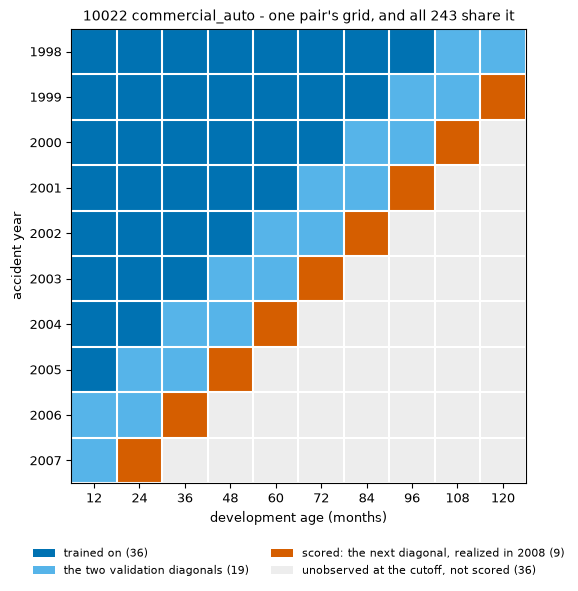

10 accident years x 10 development ages = 100 cells: 55 observed at 2007-12-31 (19 of them held out for validation), 9 scored, 36 unobserved.
cells excluded from the next diagonal on this pair: 0


In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def _locations(frame):
    """(origin_period, dev_lag) pairs of a frame, as a hashable set."""
    return frozenset(
        zip(
            pd.to_datetime(frame["origin_period"]).dt.date,
            frame["dev_lag"].astype(int),
            strict=True,
        )
    )


_tr = tri.as_of(AS_OF).expr.execute()
_tr = _tr[_tr["field"] == FIELD]
_observed = {k: _locations(g) for k, g in _tr.groupby(["company_code", "line_of_business"])}
_scored = {k: _locations(v.frame) for k, v in cells.items()}
_beyond = {k: _locations(v.excluded) for k, v in cells.items()}

# One grid speaks for the cohort set only if every pair has that grid: same accident
# years, same development ages, same scored locations, same exclusions.
assert len({(_observed[k], _scored[k], _beyond[k]) for k in PAIRS}) == 1

_key = PAIRS[0]
_origins = sorted({o for o, _ in _observed[_key]})
_devs = sorted({d for _, d in _observed[_key] | _scored[_key]})
_oi = {o: i for i, o in enumerate(_origins)}
_di = {d: j for j, d in enumerate(_devs)}
_cal = {(o, d): _oi[o] + _di[d] for o in _origins for d in _devs}
_last_train = max(_cal[c] for c in _observed[_key])
VAL_DIAGONALS = 2

_TRAIN, _VALID, _SCORED, _FUTURE = 0, 1, 2, 3
_grid_img = np.full((len(_origins), len(_devs)), _FUTURE)
for _o, _d in _observed[_key]:
    _grid_img[_oi[_o], _di[_d]] = _VALID if _cal[(_o, _d)] > _last_train - VAL_DIAGONALS else _TRAIN
for _o, _d in _scored[_key]:
    _grid_img[_oi[_o], _di[_d]] = _SCORED

_colors = ["#0072B2", "#56B4E9", "#D55E00", "#EDEDED"]
_labels = [
    f"trained on ({int((_grid_img == _TRAIN).sum())})",
    f"the two validation diagonals ({int((_grid_img == _VALID).sum())})",
    f"scored: the next diagonal, realized in 2008 ({int((_grid_img == _SCORED).sum())})",
    f"unobserved at the cutoff, not scored ({int((_grid_img == _FUTURE).sum())})",
]

fig, ax = plt.subplots(figsize=(7.2, 5.8), layout="constrained")
ax.imshow(_grid_img, cmap=ListedColormap(_colors), vmin=0, vmax=3)
ax.set_xticks(range(len(_devs)), [str(d) for d in _devs], fontsize=9)
ax.set_yticks(range(len(_origins)), [str(o.year) for o in _origins], fontsize=9)
ax.set_xticks(np.arange(-0.5, len(_devs)), minor=True)
ax.set_yticks(np.arange(-0.5, len(_origins)), minor=True)
ax.grid(which="minor", color="white", lw=1.5)
ax.tick_params(which="minor", length=0)
ax.set_xlabel("development age (months)", fontsize=9)
ax.set_ylabel("accident year", fontsize=9)
ax.set_title(f"{_key[0]} {_key[1]} - one pair's grid, and all {len(PAIRS)} share it", fontsize=10)
ax.legend(
    handles=[Patch(facecolor=c, label=t) for c, t in zip(_colors, _labels, strict=True)],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=8,
    frameon=False,
)
plt.show()

print(
    f"{len(_origins)} accident years x {len(_devs)} development ages = {_grid_img.size} cells: "
    f"{int((_grid_img < _SCORED).sum())} observed at {AS_OF} "
    f"({int((_grid_img == _VALID).sum())} of them held out for validation), "
    f"{int((_grid_img == _SCORED).sum())} scored, "
    f"{int((_grid_img == _FUTURE).sum())} unobserved."
)
print(f"cells excluded from the next diagonal on this pair: {len(_beyond[_key])}")

## Entry capabilities

A forecast carries two independent capabilities, and the separation is what lets one board
hold entries of very different shapes:

* `ScoresHeldout` -> `log_lik_at()` -> a normalized predictive density;
* `PredictsHeldout` -> `predict_at()` -> predictive draws, and hence CRPS.

The continuous ranked probability score (CRPS) generalizes absolute error to a
distributional forecast: it is the average absolute difference between a draw from the
forecast and the realized value, less half the average absolute difference between two
independent draws. For a point forecast it reduces to absolute error; lower is better.

A third column matters in this notebook and did not in the earlier ones: whether the entry
has a **native point**. `mack`, `mcl` and `tlrn` each compute a deterministic forecast that
is not the mean of their draws, and `reserve_rows(point="native")` reads it. Everything
else contributes the draw mean, and the reserve table records which.

Two rows are new. `mcl` is the full-matrix multivariate chain ladder; like `sur` it
subclasses neither held-out mixin, so neither appears in a per-cell score column. `tlrn`
has draws, but only one per company, so it subclasses neither mixin either: a company-level
spread cannot answer a per-cell question, and claiming the capability would put a company's
uncertainty on cells that never carried one.

The unit a fit covers differs too. `mack` is one company-line pair. `mcl` and `sur` are one
company each. The pooled neural entries and `tlrn` are fitted once over the whole cohort
set.

In [10]:
COHORT_UNIT = {
    "mack": "company-line pair",
    "mcl": "company",
    "sur": "company",
    "tlrn": "all companies, one fit",
    "nn_transformer": "all pairs, one fit",
    "nn_transformer_ml": "all companies, one fit",
    "deeptriangle": "all pairs, one fit",
    "mdn": "all pairs, one fit",
    "resnet": "all pairs, one fit",
}
roster = (
    pd.DataFrame(
        [
            {
                "entry": name,
                "family": cls.family,
                "density": issubclass(cls, ScoresHeldout),
                "draws (CRPS)": issubclass(cls, PredictsHeldout),
                "native point": callable(getattr(cls, "point", None)),
                "cohort unit": COHORT_UNIT.get(name, "-"),
                "config_class": getattr(cls.config_class, "__name__", "-"),
            }
            for name in gallery.list()
            for cls in [gallery.get(name)]
        ]
    )
    .sort_values(["family", "entry"])
    .reset_index(drop=True)
)
print(
    f"{len(roster)} registered entries; "
    f"{roster['density'].sum()} density, {roster['draws (CRPS)'].sum()} draws, "
    f"{roster['native point'].sum()} native point"
)
IN_THIS_STUDY = list(COHORT_UNIT)
display(roster[roster["entry"].isin(IN_THIS_STUDY)].reset_index(drop=True))

18 registered entries; 10 density, 14 draws, 3 native point


,entry,family,density,draws (CRPS),native point,cohort unit,config_class
0,mack,deterministic,False,True,True,company-line pair,-
1,deeptriangle,nn,True,True,False,"all pairs, one fit",DeepTriangleConfig
2,mdn,nn,True,True,False,"all pairs, one fit",MDNConfig
3,nn_transformer,nn,True,True,False,"all pairs, one fit",TransformerConfig
4,nn_transformer_ml,nn,True,True,False,"all companies, one fit",TransformerMLConfig
5,resnet,nn,True,True,False,"all pairs, one fit",ResNetConfig
6,tlrn,nn,False,False,True,"all companies, one fit",TLRNConfig
7,mcl,statistical,False,False,True,company,-
8,sur,statistical,False,False,False,company,-


## The scoring helpers

Four helpers carry the notebook. They are written out in full because they are the API
surface it exists to show.

`forecast_for` turns one fitted entry and one pair's held-out cells into one
`CohortForecast`. `Absence` is why a missing array is never a bare `None`: a board has to
distinguish an entry with no density at all from a run that refused one cohort. The
vocabulary is closed - `fit_failed`, `no_cell_sampler`, `no_predictive_density`,
`not_offered`, `scorer_not_implemented`, `scoring_refused`.

`reserves_for` is `reserve_rows` with this study's arguments filled in, plus the model
name. It is what the 120-month and company boards are built from.

`next_points_for` reads each model's deterministic forecast at the nine held-out cells. The
four routes differ because the models do: `mack` reads its completed triangle, `mcl` and
`sur` take one step of their fitted transitions from the latest diagonal, `tlrn` reads its
projected cumulative grid, and the pooled neural entries take the mean of their rollout
draws.

`record` keeps a refusal instead of ending the run.

In [11]:
refusals: list[dict] = []
fit_seconds: dict[str, float] = {}


def forecast_for(name, entry, key, *, field=FIELD, task=TASK):
    """One fitted entry + one pair's held-out cells -> one CohortForecast."""
    kw = {}
    if isinstance(entry, ScoresHeldout):
        try:
            kw["log_density"] = entry.log_lik_at(cells[key], field=field)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="density", error=repr(exc)[:200]))
            kw["density_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        # Permanent and about the ENTRY: it states no observation model.
        kw["density_absence"] = Absence("no_predictive_density")

    if isinstance(entry, PredictsHeldout):
        try:
            kw["draws"] = entry.predict_at(cells[key], field=field, seed=SEED_DRAW)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="draws", error=repr(exc)[:200]))
            kw["draws_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        kw["draws_absence"] = Absence("no_cell_sampler")

    return CohortForecast(model=name, task=task, cells=cells[key], field=field, **kw)


def reserves_for(name, entry, *, point, predict_kwargs=None):
    """reserve_rows with this study's arguments, tagged with the model name.

    `tri` is handed in as the full triangle for every entry. It already carries the
    selected pairs only, so a company's anchor cannot pick up a line the selection
    dropped, and it is restricted to the ten study accident years, so the 120-month
    outcome cannot pick up a later one.
    """
    rows = reserve_rows(
        entry,
        tri,
        as_of=AS_OF,
        loss_field=FIELD,
        premium_field=PREMIUM_FIELD,
        point=point,
        predict_kwargs=dict(predict_kwargs or {}),
    )
    return rows.assign(model=name)


def held_out_frame(key):
    """One pair's nine held-out cells, ordered as the entry's arrays are."""
    return cells[key].frame


def record(what, name, key, exc):
    """Keep a refusal rather than ending the run."""
    refusals.append(dict(model=name, cohort=key, axis=what, error=repr(exc)[:200]))


def refusal_summary():
    """The refusals so far, grouped, because one line per cohort would bury them."""
    if not refusals:
        return pd.DataFrame(columns=["model", "axis", "error (truncated)", "cohorts"])
    frame = pd.DataFrame(refusals)
    frame["error (truncated)"] = frame["error"].str.slice(0, 80)
    return (
        frame.groupby(["model", "axis", "error (truncated)"], as_index=False)
        .agg(cohorts=("cohort", "nunique"))
        .sort_values(["model", "axis"])
        .reset_index(drop=True)
    )


print(
    "helpers defined:",
    ", ".join(["forecast_for", "reserves_for", "held_out_frame", "record", "refusal_summary"]),
)

helpers defined: forecast_for, reserves_for, held_out_frame, record, refusal_summary


## Models and fitting

Every entry is fitted with exactly the arguments in the next cell. Nothing is tuned per
company.

The fits differ in what one fit covers, and the difference matters when the seconds are
read. `mack` is fitted separately on each of the 243 company-line pairs. `mcl` and `sur`
are fitted once per company, jointly over that company's selected lines. The neural
entries and `tlrn` are each fitted once over the whole cohort set, and that one fit
supplies every company's forecast. Pooling is how these models are designed to be used - a
single Schedule P triangle carries 55 usable cells in this window, far too few to train a
network - but it means a neural forecast draws on the loss history of all 93 companies
while the `mack` forecast beside it draws on one. The limitations section says what the
asymmetry costs the comparison.

`tlrn` is fitted three times:

* **paid only**, the eight-feature form, under the companion study's own checkpoint
  protocol;
* **with incurred loss and case reserve**, the thirteen-feature form, same protocol;
* **the same thirteen features with early stopping on**, `patience=120` validation checks
  at `check_every=5`, which is 600 epochs. The protocol's own `patience=600` never fires
  inside its 3000-epoch budget, so the difference between these two rows is whether a
  member is allowed to stop.

For each `tlrn` fit the selection table is printed: every trained member, the epoch its
best validation score came from, that score, and whether the member was kept.

Under the smoke protocol the two thirteen-feature rows can come out identical. Thirty
epochs is six validation checks, which is too few for a patience of 120 checks and a
patience of two to part company, so the two fits keep the same checkpoint. Under the
published protocol they are 3000 epochs and 600 checks apart and they do not.

In [12]:
from ibnr.gallery.nn.tlrn.config import TLRNConfig

# The transfer budget for the pooled neural entries, and the companion study's own
# protocol for tlrn. Under "smoke" both shrink to a few epochs and two seeds.
BUDGETS = {
    "published": {
        "nn": dict(
            max_epochs=120,
            patience=15,
            ensemble_size=5,
            n_draws=500,
            val_diagonals=2,
            min_cutoff=2,
        ),
        "tlrn": dict(),
        "tlrn_early": dict(patience=120),
    },
    "smoke": {
        "nn": dict(
            max_epochs=3,
            patience=15,
            ensemble_size=2,
            n_draws=50,
            val_diagonals=2,
            min_cutoff=2,
        ),
        "tlrn": dict(
            ensemble_size=2,
            keep=1,
            max_epochs=30,
            min_epochs=0,
            check_every=5,
            patience=100,
            n_draws=500,
        ),
        "tlrn_early": dict(
            ensemble_size=2,
            keep=1,
            max_epochs=30,
            min_epochs=0,
            check_every=5,
            patience=2,
            n_draws=500,
        ),
    },
}
NN_BUDGET = BUDGETS[PROTOCOL]["nn"]
TLRN_BUDGET = BUDGETS[PROTOCOL]["tlrn"]
TLRN_EARLY_BUDGET = BUDGETS[PROTOCOL]["tlrn_early"]

# mack is deterministic: fit() takes no seed, and the randomness is in predict() and
# predict_at(), which these knobs configure.
MACK_KWARGS = dict(sigma_rule="mack", heldout_n_draws=10_000)
# Every endpoint and company-level distribution is read from the SAME number of draws,
# whichever model produced it. A sample CRPS and a sample percentile both depend on the
# draw count, so a model given more draws than its neighbours would be compared on a
# different estimator rather than on a different forecast. The neural rollout budget is
# the binding one, so it sets the count for all of them.
N_DRAWS_ENDPOINT = NN_BUDGET["n_draws"]

_rows = [
    {"row": "mack", "unit": f"company-line pair x {len(PAIRS)}", "settings": str(MACK_KWARGS)},
    {"row": "mcl", "unit": f"company x {len(COMPANIES)}", "settings": "defaults"},
    {"row": "sur", "unit": f"company x {len(COMPANIES)}", "settings": "defaults"},
]
_rows += [
    {"row": n, "unit": "one pooled fit", "settings": str(NN_BUDGET)}
    for n in [
        "nn_transformer",
        "nn_transformer_pic",
        "nn_transformer_ml",
        "deeptriangle",
        "mdn",
        "resnet",
    ]
]
_rows += [
    {"row": "tlrn_8", "unit": "one pooled fit", "settings": f"TLRNConfig({TLRN_BUDGET})"},
    {"row": "tlrn_13", "unit": "one pooled fit", "settings": f"TLRNConfig({TLRN_BUDGET})"},
    {
        "row": "tlrn_13_early",
        "unit": "one pooled fit",
        "settings": f"TLRNConfig({TLRN_EARLY_BUDGET})",
    },
]
print(f"protocol {PROTOCOL}; endpoint and company draws n_draws={N_DRAWS_ENDPOINT}")
display(pd.DataFrame(_rows))

protocol smoke; endpoint and company draws n_draws=50


,row,unit,settings
0,mack,company-line pair x 243,"{'sigma_rule': 'mack', 'heldout_n_draws': 10000}"
1,mcl,company x 93,defaults
2,sur,company x 93,defaults
3,nn_transformer,one pooled fit,"{'max_epochs': 3, 'patience': 15, 'ensemble_si..."
4,nn_transformer_pic,one pooled fit,"{'max_epochs': 3, 'patience': 15, 'ensemble_si..."
5,nn_transformer_ml,one pooled fit,"{'max_epochs': 3, 'patience': 15, 'ensemble_si..."
6,deeptriangle,one pooled fit,"{'max_epochs': 3, 'patience': 15, 'ensemble_si..."
7,mdn,one pooled fit,"{'max_epochs': 3, 'patience': 15, 'ensemble_si..."
8,resnet,one pooled fit,"{'max_epochs': 3, 'patience': 15, 'ensemble_si..."
9,tlrn_8,one pooled fit,"TLRNConfig({'ensemble_size': 2, 'keep': 1, 'ma..."


### Anchors and outcomes, read once from the triangle

Every reserve on every board below is an ultimate minus an anchor, and every point error
is a predicted ultimate minus a realized one. Both come from the triangle rather than from
a model, so both are computed here, once, and every model is compared against the same
numbers.

The anchor of a company-line pair is the latest observed cumulative paid of each accident
year at 31 December 2007, summed over the ten years. The realized ultimate is the same
sum at 120 months, which this mart carries for every one of these accident years, so it is
an observed number and not an extrapolation.

`reserve_rows` computes both itself, from the triangle it is handed. The cell after the
fits asserts that its numbers agree with these to within floating-point noise, which is
what makes this a check on the plumbing rather than a second opinion.

In [13]:
_paid_all = _frame[_frame["field"] == FIELD].copy()
_paid_all["eval_date"] = pd.to_datetime(_paid_all["eval_date"])
_obs = _paid_all[_paid_all["eval_date"] <= pd.Timestamp(AS_OF)]
_latest = _obs.loc[
    _obs.groupby(["company_code", "line_of_business", "origin_period"])["dev_lag"].idxmax()
]
ANCHOR_PAIR = _latest.groupby(["company_code", "line_of_business"])["value"].sum().to_dict()
ANCHOR_COMPANY = _latest.groupby("company_code")["value"].sum().to_dict()

_endpoint = _paid_all[_paid_all["dev_lag"] == 120]
assert len(_endpoint) == len(PAIRS) * len(ORIGINS), len(_endpoint)
ULT_PAIR = _endpoint.groupby(["company_code", "line_of_business"])["value"].sum().to_dict()
ULT_COMPANY = _endpoint.groupby("company_code")["value"].sum().to_dict()

RESERVE_COMPANY = {c: ULT_COMPANY[c] - ANCHOR_COMPANY[c] for c in COMPANIES}
_r = pd.Series(RESERVE_COMPANY)
print(f"{len(ANCHOR_PAIR)} pair anchors, {len(ANCHOR_COMPANY)} company anchors")
print(
    f"actual company reserve (USD thousands): min {_r.min():,.0f}, "
    f"median {_r.median():,.0f}, max {_r.max():,.0f}, total {_r.sum():,.0f}"
)
print(
    f"on the {len(BOARD_COMPANIES)} board companies, total actual reserve "
    f"{sum(RESERVE_COMPANY[c] for c in BOARD_COMPANIES):,.0f}"
)

243 pair anchors, 93 company anchors
actual company reserve (USD thousands): min -2,689, median 18,638, max 15,208,439, total 23,579,782
on the 82 board companies, total actual reserve 22,940,015


In [14]:
# mack: one fit per pair. Each fit carries the held-out draws the cell board scores, the
# native chain-ladder point the reserve boards use, and the completed triangle the
# next-diagonal points are read from.
forecasts: list[CohortForecast] = []
reserve_parts: list[pd.DataFrame] = []
next_point_rows: list[dict] = []
endpoint_draws: dict[tuple[str, tuple], np.ndarray] = {}
company_draws: dict[tuple[str, str], np.ndarray] = {}

_dev_index = {12 * (d + 1): d for d in range(len(ORIGINS))}
_origin_index = {o: w for w, o in enumerate(ORIGINS)}


def _next_points(model, key, values):
    """One row per held-out cell: what `model` forecast there, and what happened."""
    frame = cells[key].frame
    for (_, cell), predicted in zip(frame.iterrows(), np.asarray(values, float), strict=True):
        next_point_rows.append(
            dict(
                model=model,
                company_code=key[0],
                line_of_business=key[1],
                origin_period=pd.Timestamp(cell["origin_period"]).date(),
                dev_lag=int(cell["dev_lag"]),
                predicted=float(predicted),
                actual=float(cell["value"]),
                premium=float(cell["premium"]),
            )
        )


def native_row_without_draws(model, entry, key):
    """The row `reserve_rows` would have produced for an entry whose DRAWS refuse.

    `reserve_rows` reads `predict()`'s targets to locate the total row and to record a
    draw count, so it calls `predict()` even when it is asked for a native point. mack
    refuses to simulate from a non-positive latest diagonal, and two of the board
    companies report zero paid at twelve months on their newest accident year - yet
    mack's point estimate does not depend on that cell, and its own error message says
    so. Dropping the row would take one line out of that company's reserve and leave a
    company total short by a whole line that still looks plausible, so the row is
    rebuilt here from `point()` and the anchors this notebook already read from the
    triangle. `n_draws` of 0 is what marks it on the frame.
    """
    frame = entry.point()
    labels = frame["label"].astype(str).tolist()
    ultimate = float(frame["point"].iloc[labels.index("total")])
    anchor = ANCHOR_PAIR[key]
    outcome = ULT_PAIR[key]
    return pd.DataFrame(
        [
            {
                "company_code": key[0],
                "line_of_business": key[1],
                "predicted_ultimate": ultimate,
                "realized_ultimate": outcome,
                "anchor": anchor,
                "predicted_reserve": ultimate - anchor,
                "actual_reserve": outcome - anchor,
                "premium": PREMIUM_PAIR[key],
                "n_draws": 0,
                "point_source": "native",
                "model": model,
            }
        ]
    )


t0 = time.perf_counter()
for key in PAIRS:
    try:
        entry = gallery.fit("mack", sub[key], loss_field=FIELD, as_of=AS_OF, **MACK_KWARGS)
    except Exception as exc:
        record("fit", "mack", key, exc)
        # The DENSITY reason stays the one mack declares everywhere else. It is a
        # model-level claim - this entry states no observation model - and align_panel
        # refuses a model-level reason that holds on some cohorts and not others, which
        # is right: a board row reading "permanent N/A" must not be contradicted by the
        # same model's own record. Only the draws axis failed here, so only it says so.
        forecasts.append(
            CohortForecast.unavailable(
                model="mack",
                task=TASK,
                cells=cells[key],
                field=FIELD,
                density_reason="no_predictive_density",
                draws_reason="fit_failed",
                detail=f"{type(exc).__name__}: {exc}"[:150],
            )
        )
        continue
    forecasts.append(forecast_for("mack", entry, key))
    # the completed triangle: mack's own deterministic forecast at each held-out cell
    full = np.asarray(entry.fit_.full, dtype=float)
    _next_points(
        "mack",
        key,
        [
            full[
                _origin_index[pd.Timestamp(r["origin_period"]).date()],
                _dev_index[int(r["dev_lag"])],
            ]
            for _, r in cells[key].frame.iterrows()
        ],
    )
    try:
        reserve_parts.append(
            reserves_for(
                "mack",
                entry,
                point="native",
                predict_kwargs=dict(seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT),
            )
        )
        _pred = entry.predict(segment=None, seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT)
        _labels = _pred.targets["label"].astype(str).tolist()
        endpoint_draws[("mack", key)] = np.asarray(
            _pred.samples[:, _labels.index("total")], dtype=float
        )
    except Exception as exc:
        record("reserve", "mack", key, exc)
        reserve_parts.append(native_row_without_draws("mack", entry, key))
    del entry
fit_seconds["mack"] = round(time.perf_counter() - t0, 1)
print(
    f"mack: {len(PAIRS)} pair fits in {fit_seconds['mack']:.1f}s "
    f"({fit_seconds['mack'] / len(PAIRS):.2f}s per pair); "
    f"{sum(1 for r in refusals if r['model'] == 'mack')} refusals",
    flush=True,
)

mack: 243 pair fits in 374.6s (1.54s per pair); 20 refusals


### The two multivariate chain ladders

`mcl` regresses every line's next cumulative on **every** line's current cumulative - a
full coefficient matrix per development transition. `sur` is the diagonal special case,
one slope per line, with the cross-line dependence living only in the residual covariance.
Both are fitted once per company over that company's selected lines.

Two things to expect. `mcl` refuses the eleven companies the selection section listed, by
name, because a development transition would divide by a non-positive cumulative. And on a
ten by ten square with four lines only the first transitions have enough origin pairs to
estimate a full matrix as a system; the rest fall back to the volume-weighted chain
ladder per line. That is the truth of the method on this much data rather than a
limitation of the port, and the fallback count is printed.

`sur` has no `point()`, so its reserve rows are read from the mean of its draws and the
`point_source` column says so. `mack` and `mcl` both have one.

In [15]:
mcl_fits: dict[str, object] = {}
sur_fits: dict[str, object] = {}
_fallbacks: list[dict] = []

for name, store, point_source in (("mcl", mcl_fits, "native"), ("sur", sur_fits, "draw_mean")):
    t0 = time.perf_counter()
    for company in COMPANIES:
        ctri = tri.filter(tri.expr.company_code == company)
        try:
            entry = gallery.fit(name, ctri, loss_field=FIELD, as_of=AS_OF)
        except Exception as exc:
            record("fit", name, (company,), exc)
            continue
        store[company] = entry
        try:
            reserve_parts.append(
                reserves_for(
                    name,
                    entry,
                    point=point_source,
                    predict_kwargs=dict(seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT),
                )
            )
            pred = entry.predict(seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT)
            labels = pred.targets["label"].astype(str).tolist()
            company_draws[(name, company)] = np.asarray(
                pred.samples[:, labels.index("total")], dtype=float
            )
            for ln in LINES_OF[company]:
                endpoint_draws[(name, (company, ln))] = np.asarray(
                    pred.samples[:, labels.index(f"{ln}/total")], dtype=float
                )
        except Exception as exc:
            record("reserve", name, (company,), exc)
        # one step of the fitted transitions from each origin's latest diagonal
        c = entry.contract_
        for ln in LINES_OF[company]:
            k = c["lobs"].index(ln)
            values = []
            for _, cell in cells[(company, ln)].frame.iterrows():
                w = _origin_index[pd.Timestamp(cell["origin_period"]).date()]
                d = _dev_index[int(cell["dev_lag"])]
                state = c["cum"][:, w, d - 1]
                tr = entry.transitions_[d - 1]
                step = tr["B"] @ state if name == "mcl" else tr["beta"][:, 0] * state
                values.append(step[k])
            _next_points(name, (company, ln), values)
        if name == "mcl":
            for d, tr in enumerate(entry.transitions_):
                _fallbacks.append(
                    dict(
                        company_code=company,
                        transition=f"{d + 1}->{d + 2}",
                        method=tr["method"],
                        origin_pairs=tr["n"],
                    )
                )
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    print(
        f"{name}: {len(store)} company fits in {fit_seconds[name]:.1f}s; "
        f"{len(COMPANIES) - len(store)} refused",
        flush=True,
    )

assert set(mcl_fits) == set(BOARD_COMPANIES), sorted(set(mcl_fits) ^ set(BOARD_COMPANIES))
print(f"\nmcl fitted exactly the {len(BOARD_COMPANIES)} board companies")
_fb = pd.DataFrame(_fallbacks)
print("\nmcl development transitions, by how each was estimated:")
display(_fb.groupby(["transition", "method"]).size().rename("companies").unstack(fill_value=0))
print("\nrefusals so far:")
display(refusal_summary())

mcl: 82 company fits in 133.7s; 11 refused


sur: 80 company fits in 138.1s; 13 refused



mcl fitted exactly the 82 board companies

mcl development transitions, by how each was estimated:


method,system,volume_weighted
transition,,
1->2,82,0
2->3,72,10
3->4,70,12
4->5,40,42
5->6,41,41
6->7,0,82
7->8,0,82
8->9,0,82
9->10,0,82



refusals so far:


,model,axis,error (truncated),cohorts
0,mack,draws,"ValueError(""non-positive cumulative on the lat...",7
1,mack,fit,"ValueError(""negative cumulative loss at dev st...",4
2,mack,fit,"ValueError(""negative cumulative loss at dev st...",1
3,mack,fit,"ValueError(""negative cumulative loss at dev st...",1
4,mack,reserve,"ValueError(""non-positive cumulative on the lat...",7
5,mcl,fit,"ValueError(""non-positive cumulative 'paid_loss...",2
6,mcl,fit,"ValueError(""non-positive cumulative 'paid_loss...",4
7,mcl,fit,"ValueError(""non-positive cumulative 'paid_loss...",2
8,mcl,fit,"ValueError(""non-positive cumulative 'paid_loss...",2
9,mcl,fit,"ValueError(""non-positive cumulative 'paid_loss...",1


In [16]:
# One pooled fit per neural entry over the whole cohort set, then one held-out forecast
# per pair off it. A held-out diagonal is one forward pass per ensemble member, so the
# board's draws are cheap; the rollout that `predict` needs for the 120-month endpoint is
# paid once per (n_draws, seed) and cached, which is why every call below passes the same
# two values.
NN_ROWS = [
    ("nn_transformer", "nn_transformer", {}),
    (
        "nn_transformer_pic",
        "nn_transformer",
        dict(feature_fields=(INCURRED_FIELD, CASE_FIELD), level_fields=(CASE_FIELD,)),
    ),
    ("nn_transformer_ml", "nn_transformer_ml", {}),
    ("deeptriangle", "deeptriangle", {}),
    ("mdn", "mdn", {}),
    ("resnet", "resnet", {}),
]
nn_fits: dict[str, object] = {}

for row, entry_name, extra in NN_ROWS:
    ConfigCls = gallery.get(entry_name).config_class
    t0 = time.perf_counter()
    entry = gallery.fit(
        entry_name,
        tri,
        loss_field=FIELD,
        as_of=AS_OF,
        seed=SEED_FIT,
        config=ConfigCls(**NN_BUDGET),
        **extra,
    )
    t_fit = time.perf_counter() - t0
    nn_fits[row] = entry
    by_company = row == "nn_transformer_ml"
    for key in PAIRS:
        f = forecast_for(row, entry, key)
        forecasts.append(f)
        if f.has_draws:
            # the entry's own deterministic forecast at the held-out cells is the mean
            # of the same draws the board scores
            _next_points(row, key, f.draws.mean(axis=0))
    try:
        reserve_parts.append(
            reserves_for(
                row,
                entry,
                point="draw_mean",
                predict_kwargs=dict(seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT),
            )
        )
    except Exception as exc:
        record("reserve", row, None, exc)
    for cohort in entry.cohorts():
        pred = entry.predict(segment=cohort, seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT)
        labels = pred.targets["label"].astype(str).tolist()
        total = np.asarray(pred.samples[:, labels.index("total")], dtype=float)
        if by_company:
            company = cohort["company_code"]
            company_draws[(row, company)] = total
            for ln in LINES_OF[company]:
                endpoint_draws[(row, (company, ln))] = np.asarray(
                    pred.samples[:, labels.index(f"{ln}/total")], dtype=float
                )
        else:
            endpoint_draws[(row, (cohort["company_code"], cohort["line_of_business"]))] = total
    fit_seconds[row] = round(time.perf_counter() - t0, 1)
    print(
        f"{row:20s} {fit_seconds[row]:7.1f}s  (fit {t_fit:.1f}s + "
        f"{fit_seconds[row] - t_fit:.1f}s forecasting)",
        flush=True,
    )

nn_transformer         333.2s  (fit 21.6s + 311.6s forecasting)


nn_transformer_pic     285.5s  (fit 5.2s + 280.3s forecasting)


nn_transformer_ml      550.2s  (fit 13.6s + 536.6s forecasting)


deeptriangle           275.4s  (fit 2.8s + 272.6s forecasting)


mdn                    252.2s  (fit 2.0s + 250.2s forecasting)


resnet                 214.0s  (fit 2.7s + 211.3s forecasting)


In [17]:
# The three tlrn fits. They run one after another: a notebook cell's functions are
# defined in __main__, which a spawned process on Windows cannot import, so the
# process pool the plan allows for is not available from inside a notebook. The
# thread count each fit ran with is recorded in the timing table instead.
import torch

TLRN_ROWS = [
    ("tlrn_8", {}, TLRN_BUDGET),
    ("tlrn_13", dict(incurred_field=INCURRED_FIELD, case_field=CASE_FIELD), TLRN_BUDGET),
    (
        "tlrn_13_early",
        dict(incurred_field=INCURRED_FIELD, case_field=CASE_FIELD),
        TLRN_EARLY_BUDGET,
    ),
]
tlrn_fits: dict[str, object] = {}
TORCH_THREADS = torch.get_num_threads()

for row, extra, budget in TLRN_ROWS:
    t0 = time.perf_counter()
    entry = gallery.fit(
        "tlrn",
        tri,
        loss_field=FIELD,
        as_of=AS_OF,
        seed=SEED_FIT,
        config=TLRNConfig(**budget),
        **extra,
    )
    t_fit = time.perf_counter() - t0
    tlrn_fits[row] = entry
    reserve_parts.append(
        reserves_for(
            row,
            entry,
            point="native",
            predict_kwargs=dict(seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT),
        )
    )
    pred = entry.predict(seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT)
    for cj, cohort in enumerate(entry.cohorts()):
        company_draws[(row, cohort["company_code"])] = np.asarray(pred.samples[:, cj], dtype=float)
    # the projected cumulative grid: tlrn's deterministic forecast at every cell
    c = entry.contract_
    _codes = list(c["companies"]["company_code"])
    for company in COMPANIES:
        cj = _codes.index(company)
        for ln in LINES_OF[company]:
            li = list(c["lob_levels"]).index(ln)
            values = []
            for _, cell in cells[(company, ln)].frame.iterrows():
                w = _origin_index[pd.Timestamp(cell["origin_period"]).date()]
                d = _dev_index[int(cell["dev_lag"])]
                values.append(entry.point_cumulative_[cj, li, w, d])
            _next_points(row, (company, ln), values)
    fit_seconds[row] = round(time.perf_counter() - t0, 1)
    print(
        f"{row:16s} {fit_seconds[row]:8.1f}s  (fit {t_fit:.1f}s on "
        f"{TORCH_THREADS} torch threads, {len(entry.models_)} checkpoint(s) kept)",
        flush=True,
    )
    print(f"  members trained: {len(entry.selection_)}; selection table:")
    display(entry.selection_)

tlrn_8              141.1s  (fit 84.0s on 16 torch threads, 1 checkpoint(s) kept)


  members trained: 2; selection table:


,member,best_epoch,epochs_run,validation_ay_line_ape,validation_company_ape,kept
0,0,30,30,0.250283,0.188971,False
1,1,25,30,0.147217,0.071783,True


tlrn_13             158.7s  (fit 92.9s on 16 torch threads, 1 checkpoint(s) kept)


  members trained: 2; selection table:


,member,best_epoch,epochs_run,validation_ay_line_ape,validation_company_ape,kept
0,0,25,30,0.162974,0.079239,False
1,1,30,30,0.127402,0.071625,True


tlrn_13_early       136.8s  (fit 64.6s on 16 torch threads, 1 checkpoint(s) kept)


  members trained: 2; selection table:


,member,best_epoch,epochs_run,validation_ay_line_ape,validation_company_ape,kept
0,0,25,30,0.162974,0.079239,False
1,1,30,30,0.127402,0.071625,True


### One frame per level

Everything the boards read is assembled here. `reserve_rows` produced one row per cohort
at each entry's own unit, so the company-unit entries have 93 rows (82 for `mcl`) and the
pair-unit entries 243. Three frames come out of it:

* `reserve_frame` - every row `reserve_rows` produced, with a `model` column;
* `company_reserves` - one row per (model, company), summed where a model works per pair;
* `pair_reserves` - one row per (model, company, line), read from the per-line totals of
  the company-unit entries' own forecasts.

The blend is formed here too. The companion study's final estimator shrinks the
transformer's company reserve toward the multivariate chain ladder's,
`shrink_toward(tlrn, mcl, 0.658)`. The weight is the study's supplied constant; it was
not searched here, and the limitations section says so.

In [18]:
reserve_frame = pd.concat(reserve_parts, ignore_index=True)
print(f"{len(reserve_frame)} reserve rows over {reserve_frame['model'].nunique()} models")
display(
    reserve_frame.groupby(["model", "point_source"])
    .agg(rows=("predicted_reserve", "size"), companies=("company_code", "nunique"))
    .reset_index()
)

# THE PLUMBING CHECK. reserve_rows read the anchor and the realized ultimate from the
# triangle itself; so did the anchors cell, by a different route. A disagreement would
# mean one of the two is looking at different cells.
_pairwise = reserve_frame[reserve_frame["line_of_business"].notna()]
_a = _pairwise.apply(lambda r: ANCHOR_PAIR[(r["company_code"], r["line_of_business"])], axis=1)
_u = _pairwise.apply(lambda r: ULT_PAIR[(r["company_code"], r["line_of_business"])], axis=1)
_anchor_gap = float((_pairwise["anchor"] - _a).abs().max())
_ult_gap = float((_pairwise["realized_ultimate"] - _u).abs().max())
_cw = reserve_frame[reserve_frame["line_of_business"].isna()]
_ca = float((_cw["anchor"] - _cw["company_code"].map(ANCHOR_COMPANY)).abs().max())
_cu = float((_cw["realized_ultimate"] - _cw["company_code"].map(ULT_COMPANY)).abs().max())
print(
    f"\nlargest disagreement with the triangle, pair rows:    anchor {_anchor_gap:.3e}, outcome {_ult_gap:.3e}"
)

# THE COVERAGE CHECK. A company reserve summed from fewer lines than the company writes
# is plausible and wrong, so a model missing a line on a board company is refused here
# rather than printed. Companies off the board may legitimately be missing: mack refuses
# a line with a negative cumulative, and eleven companies have one.
for _model, _g in reserve_frame[reserve_frame["line_of_business"].notna()].groupby("model"):
    _n = _g.groupby("company_code")["line_of_business"].nunique()
    _short = {
        c: int(_n.get(c, 0)) for c in BOARD_COMPANIES if int(_n.get(c, 0)) != len(LINES_OF[c])
    }
    assert not _short, f"{_model} covers fewer lines than the company writes: {_short}"
print(f"every pair-unit model covers every line of all {len(BOARD_COMPANIES)} board companies")
print(f"largest disagreement with the triangle, company rows: anchor {_ca:.3e}, outcome {_cu:.3e}")
assert max(_anchor_gap, _ult_gap, _ca, _cu) < 1e-6

# company level: sum the pair-unit models within the company, keep the company-unit
# models as they are
_per_company = level_errors(
    reserve_frame,
    predicted="predicted_reserve",
    actual="actual_reserve",
    level=["model", "company_code"],
).rename(columns={"predicted": "predicted_reserve", "actual": "actual_reserve"})
company_reserves = _per_company.copy()
company_reserves["premium"] = company_reserves["company_code"].map(PREMIUM_COMPANY)

# the blend, on the companies mcl fitted
_mcl = company_reserves[company_reserves["model"] == "mcl"].set_index("company_code")
BLEND_ROWS = {
    "tlrn_8": "tlrn_8_blend",
    "tlrn_13": "tlrn_13_blend",
    "tlrn_13_early": "tlrn_13_early_blend",
}
_blend_parts = []
BLENDED_POINT: dict[str, np.ndarray] = {}
for src, dest in BLEND_ROWS.items():
    _src = company_reserves[company_reserves["model"] == src].set_index("company_code")
    _shared = [c for c in BOARD_COMPANIES if c in _src.index and c in _mcl.index]
    blended = shrink_toward(
        _src.loc[_shared, "predicted_reserve"].to_numpy(),
        _mcl.loc[_shared, "predicted_reserve"].to_numpy(),
        BLEND_WEIGHT,
    )
    BLENDED_POINT[dest] = dict(zip(_shared, blended, strict=True))
    _blend_parts.append(
        pd.DataFrame(
            {
                "model": dest,
                "company_code": _shared,
                "n_rows": _src.loc[_shared, "n_rows"].to_numpy(),
                "predicted_reserve": blended,
                "actual_reserve": _src.loc[_shared, "actual_reserve"].to_numpy(),
                "error": blended - _src.loc[_shared, "actual_reserve"].to_numpy(),
                "premium": [PREMIUM_COMPANY[c] for c in _shared],
            }
        )
    )
company_reserves = pd.concat([company_reserves, *_blend_parts], ignore_index=True)
print(
    f"\n{company_reserves['model'].nunique()} company-level rows, including "
    f"{len(BLEND_ROWS)} blended at alpha = {BLEND_WEIGHT} (supplied, not searched)"
)
display(
    company_reserves.groupby("model")["company_code"].nunique().rename("companies").to_frame().T
)

1986 reserve rows over 12 models


,model,point_source,rows,companies
0,deeptriangle,draw_mean,243,93
1,mack,native,237,93
2,mcl,native,82,82
3,mdn,draw_mean,243,93
4,nn_transformer,draw_mean,243,93
5,nn_transformer_ml,draw_mean,93,93
6,nn_transformer_pic,draw_mean,243,93
7,resnet,draw_mean,243,93
8,sur,draw_mean,80,80
9,tlrn_13,native,93,93



largest disagreement with the triangle, pair rows:    anchor 0.000e+00, outcome 0.000e+00
every pair-unit model covers every line of all 82 board companies
largest disagreement with the triangle, company rows: anchor 0.000e+00, outcome 0.000e+00

15 company-level rows, including 3 blended at alpha = 0.658 (supplied, not searched)


model,deeptriangle,mack,mcl,mdn,nn_transformer,nn_transformer_ml,nn_transformer_pic,resnet,sur,tlrn_13,tlrn_13_blend,tlrn_13_early,tlrn_13_early_blend,tlrn_8,tlrn_8_blend
companies,93,93,82,93,93,93,93,93,80,93,82,93,82,93,82


In [19]:
# The pair level for every model that has a per-line number. Pair-unit models bring
# theirs from reserve_rows; the company-unit models' per-line totals are read off their
# own point frame (mcl, tlrn) or the per-line total rows of their draws (sur,
# nn_transformer_ml), minus that pair's anchor.
pair_parts = [
    reserve_frame.loc[
        reserve_frame["line_of_business"].notna(),
        ["model", "company_code", "line_of_business", "predicted_reserve", "actual_reserve"],
    ]
]
_line_rows: list[dict] = []
for name, store in (
    ("mcl", mcl_fits),
    ("tlrn_8", None),
    ("tlrn_13", None),
    ("tlrn_13_early", None),
    ("sur", sur_fits),
    ("nn_transformer_ml", None),
):
    for company in COMPANIES:
        for ln in LINES_OF[company]:
            anchor = ANCHOR_PAIR[(company, ln)]
            if name in ("mcl",):
                entry = store.get(company)
                if entry is None:
                    continue
                frame = entry.point()
                ult = float(frame.loc[frame["label"] == f"{ln}/total", "point"].iloc[0])
            elif name.startswith("tlrn"):
                entry = tlrn_fits[name]
                frame = entry.point(segment={"company_code": company})
                ult = float(frame.loc[frame["label"] == f"{ln}/total", "point"].iloc[0])
            else:
                draws = endpoint_draws.get((name, (company, ln)))
                if draws is None:
                    continue
                ult = float(draws.mean())
            _line_rows.append(
                dict(
                    model=name,
                    company_code=company,
                    line_of_business=ln,
                    predicted_reserve=ult - anchor,
                    actual_reserve=ULT_PAIR[(company, ln)] - anchor,
                )
            )
pair_reserves = pd.concat([*pair_parts, pd.DataFrame(_line_rows)], ignore_index=True)
print(f"{len(pair_reserves)} pair rows over {pair_reserves['model'].nunique()} models")
display(pair_reserves.groupby("model").size().rename("pairs").to_frame().T)

2844 pair rows over 12 models


model,deeptriangle,mack,mcl,mdn,nn_transformer,nn_transformer_ml,nn_transformer_pic,resnet,sur,tlrn_13,tlrn_13_early,tlrn_8
pairs,243,237,212,243,243,243,243,243,208,243,243,243


## Results at the three levels

### The next calendar diagonal

The first level is one paid cell: the nine cells of each pair realized during calendar
2008, 2,187 in all. Two scores run on it. CRPS reads the predictive draws of the entries
that have them, and `align_panel` first narrows to the cells every one of those entries
answered for, so the number on each row rests on the same cells. Point error reads each
entry's own deterministic forecast at the same cells, and every entry here has one.

In [20]:
aligned = align_panel(forecasts, units=tri.meta.units)
print(f"task {aligned.task} @ {aligned.as_of}")
print(
    f"CRPS: {aligned.n_cells_for('crps')} cells over {aligned.n_cohorts_for('crps')} pairs, in {aligned.units}"
)
print("      models the score covers:", list(aligned.crps_members))
print("      cell set hash           ", aligned.crps_fingerprint)
print("      cells dropped           ", len(aligned.dropped))
board = gallery.leaderboard(aligned)
print("\nscore direction:", {k: v for k, v in SCORE_DIRECTION.items() if k.startswith("crps")})
display(
    board[["model", "n_cohorts", "n_cells_crps", "crps", "crps_per_cell", "n_draws_sample_min"]]
    .sort_values("crps_per_cell")
    .round(3)
)
if len(aligned.dropped):
    print("\ndropped cells by score:", aligned.dropped["score"].value_counts().to_dict())
    display(aligned.dropped.head(10))

task paid_loss@2007 @ 2007-12-31
CRPS: 2070 cells over 230 pairs, in USD thousands
      models the score covers: ['deeptriangle', 'mack', 'mdn', 'nn_transformer', 'nn_transformer_ml', 'nn_transformer_pic', 'resnet']
      cell set hash            2f84696277cec0d5
      cells dropped            117

score direction: {'crps': 'lower_is_better', 'crps_per_cell': 'lower_is_better'}


,model,n_cohorts,n_cells_crps,crps,crps_per_cell,n_draws_sample_min
1,mack,230,2070,697943.14,337.171,10000
4,nn_transformer_ml,230,2070,2414495.279,1166.423,10000
6,resnet,230,2070,3243966.823,1567.134,10000
2,mdn,230,2070,3466498.113,1674.637,10000
0,deeptriangle,230,2070,4174342.181,2016.59,10000
3,nn_transformer,230,2070,4237510.905,2047.107,10000
5,nn_transformer_pic,230,2070,4878387.099,2356.709,10000



dropped cells by score: {'crps': 117}


,score,task,as_of,company_code,line_of_business,field,origin_period,dev_lag,missing_from
0,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,1999-01-01,120,"(mack,)"
1,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,2000-01-01,108,"(mack,)"
2,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,2001-01-01,96,"(mack,)"
3,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,2002-01-01,84,"(mack,)"
4,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,2003-01-01,72,"(mack,)"
5,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,2004-01-01,60,"(mack,)"
6,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,2005-01-01,48,"(mack,)"
7,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,2006-01-01,36,"(mack,)"
8,crps,paid_loss@2007,2007-12-31,10308,other_liability,paid_loss,2007-01-01,24,"(mack,)"
9,crps,paid_loss@2007,2007-12-31,13528,other_liability,paid_loss,1999-01-01,120,"(mack,)"


In [21]:
# The same cells, normalised by the origin's earned premium, and macro-averaged two ways:
# equal weight per pair, then equal weight per company. The dollar board above weights a
# cell by its size; these ask the typical-pair and typical-company question instead.
_crps_keys = set(aligned.cells.loc[aligned.cells["on_crps_panel"], "key"])
_cell_rows = []
for f in forecasts:
    if not f.has_draws:
        continue
    values = f.key_frame["value"].to_numpy(dtype=float)
    on = np.array([k in _crps_keys for k in f.keys])
    if not on.any():
        continue
    per_cell = crps(f.draws[:, on], values[on])
    kf = f.key_frame.loc[on]
    for (_, r), value in zip(kf.iterrows(), per_cell, strict=True):
        _cell_rows.append(
            dict(
                model=f.model,
                company_code=f.cohort[0],
                line_of_business=f.cohort[1],
                dev_lag=int(r["dev_lag"]),
                crps=float(value),
                premium=float(r["premium"]),
            )
        )
cell_crps = pd.DataFrame(_cell_rows)
cell_crps["crps_pct_premium"] = 100.0 * cell_crps["crps"] / cell_crps["premium"]
_by_pair = cell_crps.groupby(["model", "company_code", "line_of_business"])[
    "crps_pct_premium"
].mean()
crps_views = pd.DataFrame(
    {
        "equal_pair": _by_pair.groupby("model").mean(),
        "equal_company": _by_pair.groupby(["model", "company_code"]).mean().groupby("model").mean(),
    }
).sort_values("equal_pair")
print("cell CRPS as a percentage of the origin's earned premium, macro-averaged:")
display(crps_views.round(4))

cell CRPS as a percentage of the origin's earned premium, macro-averaged:


,equal_pair,equal_company
model,,
mack,2.3418,2.7139
resnet,2.4573,2.8691
nn_transformer_ml,2.5414,2.9455
mdn,2.6186,3.0295
deeptriangle,2.6670,3.0739
nn_transformer,2.8008,3.2063
nn_transformer_pic,2.9166,3.3164


In [22]:
# Point error at the same cells, for every model with a deterministic forecast there.
# A model that could not be fitted on a pair has no forecast at its cells, so the board
# is scored on the cells EVERY model answered for and the cost of that is printed rather
# than absorbed: a fixed cohort set is the whole point of the comparison.
next_points = pd.DataFrame(next_point_rows)
next_points["cell"] = list(
    zip(
        next_points["company_code"],
        next_points["line_of_business"],
        next_points["origin_period"],
        strict=True,
    )
)
_offered = set(next_points["cell"])
_by_model = {m: set(g["cell"]) for m, g in next_points.groupby("model")}
_shared = set.intersection(*_by_model.values())
print(f"cells offered {len(_offered)}, scored by every model {len(_shared)}")
for m, covered in sorted(_by_model.items()):
    gap = len(_offered - covered)
    if gap:
        print(f"  {m} has no forecast at {gap} of them")
scored_points = next_points[next_points["cell"].isin(_shared)]

_levels = {
    "cell": ["company_code", "line_of_business", "origin_period"],
    "pair": ["company_code", "line_of_business"],
    "company": ["company_code"],
}
_rows = []
for level, cols in _levels.items():
    for model, g in scored_points.groupby("model"):
        units = level_errors(g, predicted="predicted", actual="actual", level=cols)
        _rows.append(
            {"level": level, "model": model, **point_metrics(units["predicted"], units["actual"])}
        )
next_board = pd.DataFrame(_rows)
for level in _levels:
    print(f"\nnext diagonal, errors summed to the {level} level:")
    display(
        next_board[next_board["level"] == level]
        .drop(columns="level")
        .sort_values("pool_ape")
        .set_index("model")[["n", "pool_ape", "pool_pe", "mae", "rmse", "prop_over"]]
        .round(4)
    )

cells offered 2187, scored by every model 1872
  mack has no forecast at 54 of them
  mcl has no forecast at 279 of them
  sur has no forecast at 315 of them



next diagonal, errors summed to the cell level:


,n,pool_ape,pool_pe,mae,rmse,prop_over
model,,,,,,
sur,1872,0.0061,-0.0010,465.8407,2342.7178,0.5160
mack,1872,0.0061,-0.0011,467.9001,2375.3296,0.4861
mcl,1872,0.0069,-0.0012,528.8095,3210.2892,0.4733
tlrn_13,1872,0.0119,-0.0066,913.2983,12233.1617,0.7019
tlrn_13_early,1872,0.0119,-0.0066,913.2983,12233.1617,0.7019
tlrn_8,1872,0.0131,-0.0052,1007.0341,10659.4769,0.6934
nn_transformer_ml,1872,0.0209,0.0135,1610.9625,18935.3471,0.6848
resnet,1872,0.0245,0.0086,1887.0305,20320.4201,0.7046
nn_transformer,1872,0.0267,0.0035,2052.5890,25421.1318,0.7153



next diagonal, errors summed to the pair level:


,n,pool_ape,pool_pe,mae,rmse,prop_over
model,,,,,,
mcl,208,0.0030,-0.0012,2075.0038,6694.0533,0.4375
mack,208,0.0036,-0.0011,2482.6512,13789.9696,0.5048
sur,208,0.0036,-0.0010,2483.9369,13163.0924,0.5192
tlrn_8,208,0.0084,-0.0052,5787.4449,30764.3647,0.5817
tlrn_13_early,208,0.0088,-0.0066,6115.8181,50132.7280,0.5865
tlrn_13,208,0.0088,-0.0066,6115.8181,50132.7280,0.5865
nn_transformer,208,0.0094,0.0035,6528.5722,48210.5719,0.6683
deeptriangle,208,0.0101,0.0019,6969.7516,40530.9381,0.6298
resnet,208,0.0132,0.0086,9167.8024,87586.5218,0.6538



next diagonal, errors summed to the company level:


,n,pool_ape,pool_pe,mae,rmse,prop_over
model,,,,,,
mcl,80,0.0023,-0.0012,4121.3477,13564.1134,0.4500
sur,80,0.0027,-0.0010,4877.5876,21401.2414,0.5000
mack,80,0.0027,-0.0011,4943.8193,22425.7815,0.5000
nn_transformer,80,0.0069,0.0035,12377.2481,62076.3079,0.6375
tlrn_8,80,0.0073,-0.0052,13123.6464,57564.3975,0.5125
deeptriangle,80,0.0078,0.0019,14039.9110,56723.7909,0.5750
tlrn_13_early,80,0.0083,-0.0066,14999.9277,91967.1434,0.5750
tlrn_13,80,0.0083,-0.0066,14999.9277,91967.1434,0.5750
resnet,80,0.0105,0.0086,18984.9398,128800.0554,0.6500


In [23]:
# What summing before the absolute value does, on one company. The line errors are
# signed, so a company-level Pool_APE credits a model for overestimating one line and
# underestimating another; a line-level one does not.
CANCEL_COMPANY = "671" if "671" in COMPANIES else BOARD_COMPANIES[0]
_one = scored_points[scored_points["company_code"] == CANCEL_COMPANY]
_lines = level_errors(
    _one, predicted="predicted", actual="actual", level=["model", "line_of_business"]
)
_comp = level_errors(_one, predicted="predicted", actual="actual", level=["model"])
_show = (
    _lines.pivot(index="model", columns="line_of_business", values="error")
    .join(_comp.set_index("model")["error"].rename("company error (signed sum)"))
    .join(
        _lines.assign(abs_error=_lines["error"].abs())
        .groupby("model")["abs_error"]
        .sum()
        .rename("sum of absolute line errors")
    )
)
print(
    f"company {CANCEL_COMPANY}, next-diagonal errors by line (USD thousands). The last two "
    "columns are\nthe same errors read two ways: summed first, or absolute first."
)
display(_show.round(2))

company 671, next-diagonal errors by line (USD thousands). The last two columns are
the same errors read two ways: summed first, or absolute first.


,commercial_auto,other_liability,private_passenger_auto,workers_compensation,company error (signed sum),sum of absolute line errors
model,,,,,,
deeptriangle,701.56,433.33,-8465.98,909.23,-6421.85,10510.10
mack,-146.63,296.25,2313.54,537.61,3000.76,3294.02
mcl,-719.52,339.34,1293.11,403.17,1316.11,2755.14
mdn,1162.68,452.50,-5503.99,414.45,-3474.36,7533.62
nn_transformer,999.75,316.51,-9428.32,-890.70,-9002.75,11635.28
nn_transformer_ml,1016.21,287.70,-8807.68,4326.28,-3177.49,14437.87
nn_transformer_pic,1729.50,623.78,10369.31,1906.44,14629.03,14629.03
resnet,1134.43,146.45,-8709.04,-1091.89,-8520.04,11081.81
sur,13.23,143.24,2558.11,489.82,3204.40,3204.40


### The 120-month endpoint, per company-line pair

The second level is one company-line pair: its ten accident years' cumulative paid at 120
months, against what each model forecast for it. Every model with a per-line number is
here, including the company-unit ones, whose per-line totals come off their own forecasts.

CRPS and the probability integral transform (PIT) run on the same pairs for the models
that carry per-line draws. A PIT is the predictive distribution's own percentile at the
realized outcome; a calibrated model's PITs are uniform. There is one per pair, so the
test has 243 observations rather than 2,187 near-duplicates.

In [24]:
# Same rule as the cell board: score the pairs every model covered, and print the cost.
pair_reserves["pair"] = list(
    zip(pair_reserves["company_code"], pair_reserves["line_of_business"], strict=True)
)
_offered_pairs = set(pair_reserves["pair"])
_pairs_by_model = {m: set(g["pair"]) for m, g in pair_reserves.groupby("model")}
_shared_pairs = set.intersection(*_pairs_by_model.values())
print(f"pairs offered {len(_offered_pairs)}, scored by every model {len(_shared_pairs)}")
for m, covered in sorted(_pairs_by_model.items()):
    gap = len(_offered_pairs - covered)
    if gap:
        print(f"  {m} has no reserve for {gap} of them")
scored_pairs = pair_reserves[pair_reserves["pair"].isin(_shared_pairs)]

_rows = []
for model, g in scored_pairs.groupby("model"):
    units = level_errors(
        g,
        predicted="predicted_reserve",
        actual="actual_reserve",
        level=["company_code", "line_of_business"],
    )
    _rows.append({"model": model, **point_metrics(units["predicted"], units["actual"])})
pair_board = pd.DataFrame(_rows).sort_values("pool_ape").set_index("model")
print("\n120-month endpoint reserve, errors at the company-line pair level:")
display(
    pair_board[["n", "pool_ape", "pool_pe", "mae", "rmse", "wrmse", "medape", "prop_over"]].round(4)
)

# CRPS and PIT at the same level, for the models that carry per-line draws - on the same
# shared pairs the point board above used, so the two tables describe one set of pairs.
# The models that carry per-line draws do not all carry them on the same pairs - mack
# refuses to simulate from a non-positive latest diagonal - so this table is narrowed the
# same way the point board above was, and the cost is printed.
_draw_models = sorted({m for m, _ in endpoint_draws})
_draw_pairs = {m: {k for mm, k in endpoint_draws if mm == m} & _shared_pairs for m in _draw_models}
_shared_draw_pairs = set.intersection(*_draw_pairs.values())
print(f"pairs with draws from every model that has them: {len(_shared_draw_pairs)}")
for _m, _covered in _draw_pairs.items():
    _gap = len(_shared_pairs - _covered)
    if _gap:
        print(f"  {_m} has no draws at {_gap} of the {len(_shared_pairs)} scored pairs")

_rows = []
for model in _draw_models:
    keys = sorted(_shared_draw_pairs)
    values, prem, pits = [], [], []
    for key in keys:
        draws = endpoint_draws[(model, key)]
        actual = ULT_PAIR[key]
        values.append(float(crps(draws[:, None], np.array([actual]))[0]))
        prem.append(PREMIUM_PAIR[key])
        pits.append(float((draws <= actual).mean()))
    values, prem, pits = np.array(values), np.array(prem), np.array(pits)
    ks = ks_uniformity(pits)
    _rows.append(
        {
            "model": model,
            "pairs": len(keys),
            "mean_crps": values.mean(),
            "median_crps": float(np.median(values)),
            "mean_crps_pct_premium": float(np.mean(100.0 * values / prem)),
            "pit_mean": float(pits.mean()),
            "pit_sd": float(pits.std(ddof=1)),
            "D x 100": 100 * ks.statistic,
            "critical 5% x 100": 100 * ks.critical_value_5pct,
            "passes": not ks.reject_5pct,
        }
    )
pair_dist = pd.DataFrame(_rows).sort_values("mean_crps_pct_premium").set_index("model")
print("\nthe same pairs, scored as distributions:")
display(pair_dist.round(4))

pairs offered 243, scored by every model 208
  mack has no reserve for 6 of them
  mcl has no reserve for 31 of them
  sur has no reserve for 35 of them

120-month endpoint reserve, errors at the company-line pair level:


,n,pool_ape,pool_pe,mae,rmse,wrmse,medape,prop_over
model,,,,,,,,
mcl,208,0.0669,-0.0018,7374.6448,2.494988e+04,1.642131e+05,0.2611,0.4904
mack,208,0.0832,0.0103,9175.5035,3.577787e+04,2.784649e+05,0.2484,0.5240
sur,208,0.0847,0.0143,9338.5054,3.518083e+04,2.568300e+05,0.2479,0.5144
tlrn_8,208,0.1339,0.0467,14761.4772,5.982416e+04,5.015243e+05,0.3927,0.7308
tlrn_13_early,208,0.1817,0.1471,20029.3420,1.070747e+05,1.054414e+06,0.4462,0.8317
tlrn_13,208,0.1817,0.1471,20029.3420,1.070747e+05,1.054414e+06,0.4462,0.8317
nn_transformer_ml,208,0.2520,0.2016,27783.8960,2.109085e+05,2.274546e+06,0.3861,0.7356
deeptriangle,208,0.3886,0.3099,42843.5756,4.193473e+05,4.594548e+06,0.4162,0.7644
nn_transformer,208,0.4374,0.3561,48216.2033,4.419892e+05,4.762142e+06,0.5186,0.7933


pairs with draws from every model that has them: 208

the same pairs, scored as distributions:


,pairs,mean_crps,median_crps,mean_crps_pct_premium,pit_mean,pit_sd,D x 100,critical 5% x 100,passes
model,,,,,,,,,
nn_transformer_ml,208,19195.0210,1400.6689,3.7312,0.3407,0.2980,28.0192,9.4299,False
resnet,208,31894.5434,1397.5011,3.7976,0.3645,0.3277,27.2885,9.4299,False
deeptriangle,208,32041.7102,1557.0967,3.8700,0.3463,0.2883,27.0577,9.4299,False
mcl,208,5475.4122,933.1225,3.9608,0.5321,0.3487,14.7500,9.4299,False
nn_transformer,208,38116.2790,1970.4685,4.2949,0.3334,0.2662,31.4808,9.4299,False
mdn,208,31811.1188,1785.0358,4.5763,0.2609,0.3254,42.7500,9.4299,False
mack,208,7268.4699,849.7120,4.9637,0.5225,0.3617,16.8462,9.4299,False
nn_transformer_pic,208,86587.1284,2566.5702,5.8817,0.1938,0.2660,52.1923,9.4299,False
sur,208,6908.4133,897.1215,6.2082,0.5211,0.3615,16.5962,9.4299,False


### The company reserve, the companion study's own level

The third level is one company: its selected lines' outstanding paid through 120 months,
summed. This is the level the companion study reports, and it runs on the 82 companies
`mcl` and `mack` can both fit.

The four reference rows are constants from the 2026-09-20 replay of the reference
implementation on data loaded through ibnr. They are printed beside this notebook's own
rows, never mixed into them.

In [25]:
board82 = company_reserves[company_reserves["company_code"].isin(BOARD_COMPANIES)]
_rows = []
for model, g in board82.groupby("model"):
    if len(g) != len(BOARD_COMPANIES):
        # a fixed cohort set is the point: a model scoring on fewer companies is
        # reported with its own n and is not comparable on a pooled statistic
        print(f"note: {model} covers {len(g)} of {len(BOARD_COMPANIES)} board companies")
    _rows.append({"model": model, **point_metrics(g["predicted_reserve"], g["actual_reserve"])})
company_board = pd.DataFrame(_rows)
for name, value in REFERENCE_POOL_APE.items():
    company_board.loc[len(company_board)] = {
        "model": name,
        "n": len(BOARD_COMPANIES),
        "pool_ape": value,
    }
company_board = company_board.sort_values("pool_ape").set_index("model")
print(
    f"company reserve, {len(BOARD_COMPANIES)} companies. pool_ape is sum|error| / sum actual.\n"
    "The four reference rows carry their Pool_APE only, from the 2026-09-20 replay of the\n"
    "reference implementation on data loaded through ibnr."
)
display(
    company_board[
        ["n", "pool_ape", "pool_pe", "mae", "rmse", "wrmse", "mape", "medape", "prop_over"]
    ].round(4)
)

note: sur covers 80 of 82 board companies
company reserve, 82 companies. pool_ape is sum|error| / sum actual.
The four reference rows carry their Pool_APE only, from the 2026-09-20 replay of the
reference implementation on data loaded through ibnr.


,n,pool_ape,pool_pe,mae,rmse,wrmse,mape,medape,prop_over
model,,,,,,,,,
reference: blended transformer,82,0.0509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reference: raw transformer,82,0.0563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reference: chain ladder + MCL,82,0.0566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mcl,82,0.0566,-0.0019,15835.9238,4.584058e+04,2.406984e+05,0.9179,0.1783,0.4878
reference: chain ladder,82,0.0577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mack,82,0.0577,0.0103,16150.9548,5.854562e+04,2.986225e+05,1.1535,0.1364,0.5732
sur,80,0.0602,0.0143,17258.0771,5.895561e+04,2.805134e+05,1.6441,0.1664,0.5625
tlrn_8_blend,82,0.0797,0.0303,22303.2401,6.248319e+04,2.740480e+05,0.7034,0.2309,0.7195
tlrn_8,82,0.1135,0.0470,31765.1459,9.660570e+04,5.171959e+05,0.6664,0.3238,0.7439


In [26]:
# The company-level distributions: every model that has company draws, plus the three
# tlrn fits raw and blended. tlrn's spread is resampled from what its kept checkpoints
# got wrong at earlier cutoffs on companies of similar premium, so a blended point keeps
# the same calibration around a different centre - which is what predict_reserve_draws
# exists for.
def _interval_score(draws, actual, level):
    alpha = 1.0 - level
    lo, hi = np.quantile(draws, [alpha / 2, 1 - alpha / 2])
    return (
        (hi - lo) + (2 / alpha) * max(lo - actual, 0.0) + (2 / alpha) * max(actual - hi, 0.0)
    ), (lo <= actual <= hi)


# sum a company's line draws within a draw for the models that work per pair
for model in sorted({m for m, _ in endpoint_draws}):
    for company in COMPANIES:
        keys = [(model, (company, ln)) for ln in LINES_OF[company]]
        if (model, company) in company_draws or not all(k in endpoint_draws for k in keys):
            continue
        sizes = {len(endpoint_draws[k]) for k in keys}
        if len(sizes) != 1:
            continue
        company_draws[(model, company)] = np.sum([endpoint_draws[k] for k in keys], axis=0)

# the blended tlrn draws: calibrated around the blended reserve
for src, dest in BLEND_ROWS.items():
    entry = tlrn_fits[src]
    codes = list(entry.contract_["companies"]["company_code"])
    raw = entry.company_reserves()
    point = np.array([BLENDED_POINT[dest].get(c, raw[i]) for i, c in enumerate(codes)])
    draws = entry.predict_reserve_draws(point, seed=SEED_DRAW, n_draws=N_DRAWS_ENDPOINT)
    anchors = entry.company_anchors()
    for i, c in enumerate(codes):
        if c in BLENDED_POINT[dest]:
            company_draws[(dest, c)] = draws[:, i] + anchors[i]

# Same rule once more: every row rests on the companies every model with draws covers.
_dist_models = sorted({m for m, _ in company_draws})
_dist_codes = {m: {c for c in BOARD_COMPANIES if (m, c) in company_draws} for m in _dist_models}
_shared_codes = set.intersection(*_dist_codes.values())
print(f"board companies with draws from every model that has them: {len(_shared_codes)}")
for _m, _covered in _dist_codes.items():
    _gap = len(set(BOARD_COMPANIES) - _covered)
    if _gap:
        print(f"  {_m} has no company draws for {_gap} of the {len(BOARD_COMPANIES)}")

_rows = []
for model in _dist_models:
    codes = [c for c in BOARD_COMPANIES if c in _shared_codes]
    values, prem, pits, is80, is95, cov80, cov95 = [], [], [], [], [], [], []
    for c in codes:
        draws = company_draws[(model, c)]
        actual = ULT_COMPANY[c]
        values.append(float(crps(draws[:, None], np.array([actual]))[0]))
        prem.append(PREMIUM_COMPANY[c])
        pits.append(float((draws <= actual).mean()))
        s80, c80 = _interval_score(draws, actual, 0.80)
        s95, c95 = _interval_score(draws, actual, 0.95)
        is80.append(s80)
        is95.append(s95)
        cov80.append(c80)
        cov95.append(c95)
    values, prem, pits = np.array(values), np.array(prem), np.array(pits)
    _rows.append(
        {
            "model": model,
            "companies": len(codes),
            "mean_crps": values.mean(),
            "median_crps": float(np.median(values)),
            "mean_crps_pct_premium": float(np.mean(100.0 * values / prem)),
            "pit_mean": float(pits.mean()),
            "pit_sd": float(pits.std(ddof=1)),
            "coverage_80": float(np.mean(cov80)),
            "coverage_95": float(np.mean(cov95)),
            "mean_interval_score_80": float(np.mean(is80)),
            "mean_interval_score_95": float(np.mean(is95)),
        }
    )
company_dist = pd.DataFrame(_rows).sort_values("mean_crps_pct_premium").set_index("model")
COMPANY_PITS = {
    m: np.array(
        [float((company_draws[(m, c)] <= ULT_COMPANY[c]).mean()) for c in sorted(_shared_codes)]
    )
    for m in _dist_models
}
print(f"company-level distributions on the {len(BOARD_COMPANIES)} board companies:")
display(company_dist.round(4))

board companies with draws from every model that has them: 80
  mack has no company draws for 2 of the 82
  sur has no company draws for 2 of the 82


company-level distributions on the 82 board companies:


,companies,mean_crps,median_crps,mean_crps_pct_premium,pit_mean,pit_sd,coverage_80,coverage_95,mean_interval_score_80,mean_interval_score_95
model,,,,,,,,,,
nn_transformer_ml,80,50372.5897,3535.9521,2.7299,0.3020,0.3162,0.5125,0.7000,3.322433e+05,4.314045e+05
tlrn_13_blend,80,24048.1224,4293.8636,3.1730,0.2525,0.2849,0.5000,0.7250,1.628897e+05,2.940669e+05
tlrn_13_early_blend,80,24048.1224,4293.8636,3.1730,0.2525,0.2849,0.5000,0.7250,1.628897e+05,2.940669e+05
tlrn_8_blend,80,31554.3401,4317.6655,3.2050,0.3428,0.2800,0.7125,0.8500,3.251964e+05,4.961422e+05
deeptriangle,80,77911.0434,4806.1510,3.2401,0.3232,0.2906,0.6250,0.8375,5.310091e+05,6.649695e+05
tlrn_8,80,38791.7392,4471.9152,3.2719,0.3117,0.2935,0.6000,0.7625,3.560903e+05,6.319305e+05
resnet,80,74247.0590,5135.9185,3.3571,0.3075,0.3343,0.4500,0.7000,3.579083e+05,4.892277e+05
tlrn_13,80,33785.4386,6078.4716,3.4455,0.1768,0.2637,0.3125,0.5625,2.087660e+05,3.983148e+05
tlrn_13_early,80,33785.4386,6078.4716,3.4455,0.1768,0.2637,0.3125,0.5625,2.087660e+05,3.983148e+05


In [27]:
# tlrn's own historical coverage: each calibration forecast is covered by an interval
# built from the OTHER companies of its premium stratum, so no company's interval is
# built from its own error.
for row, entry in tlrn_fits.items():
    table = leave_one_out_coverage(entry.calibration_, levels=(0.8, 0.95))
    print(f"{row}: leave-one-out historical coverage")
    display(table.round(4))
    print(
        f"  calibrated on cutoffs {entry.config_.calibration_cutoffs}, horizons "
        f"{entry.config_.calibration_horizons}, {entry.config_.n_strata} premium strata, "
        f"{len(entry.calibration_.residuals)} residuals"
    )

tlrn_8: leave-one-out historical coverage


,horizon,nominal_coverage,empirical_coverage,forecasts
0,3,0.80,0.7419,93
1,4,0.80,0.7849,93
2,5,0.80,0.7634,93
3,3,0.95,0.9462,93
4,4,0.95,0.9462,93
5,5,0.95,0.9247,93


  calibrated on cutoffs (5, 6, 7, 8, 9), horizons (3, 4, 5), 4 premium strata, 279 residuals
tlrn_13: leave-one-out historical coverage


,horizon,nominal_coverage,empirical_coverage,forecasts
0,3,0.80,0.7097,93
1,4,0.80,0.6989,93
2,5,0.80,0.6667,93
3,3,0.95,0.8925,93
4,4,0.95,0.9032,93
5,5,0.95,0.8817,93


  calibrated on cutoffs (5, 6, 7, 8, 9), horizons (3, 4, 5), 4 premium strata, 279 residuals
tlrn_13_early: leave-one-out historical coverage


,horizon,nominal_coverage,empirical_coverage,forecasts
0,3,0.80,0.7097,93
1,4,0.80,0.6989,93
2,5,0.80,0.6667,93
3,3,0.95,0.8925,93
4,4,0.95,0.9032,93
5,5,0.95,0.8817,93


  calibrated on cutoffs (5, 6, 7, 8, 9), horizons (3, 4, 5), 4 premium strata, 279 residuals


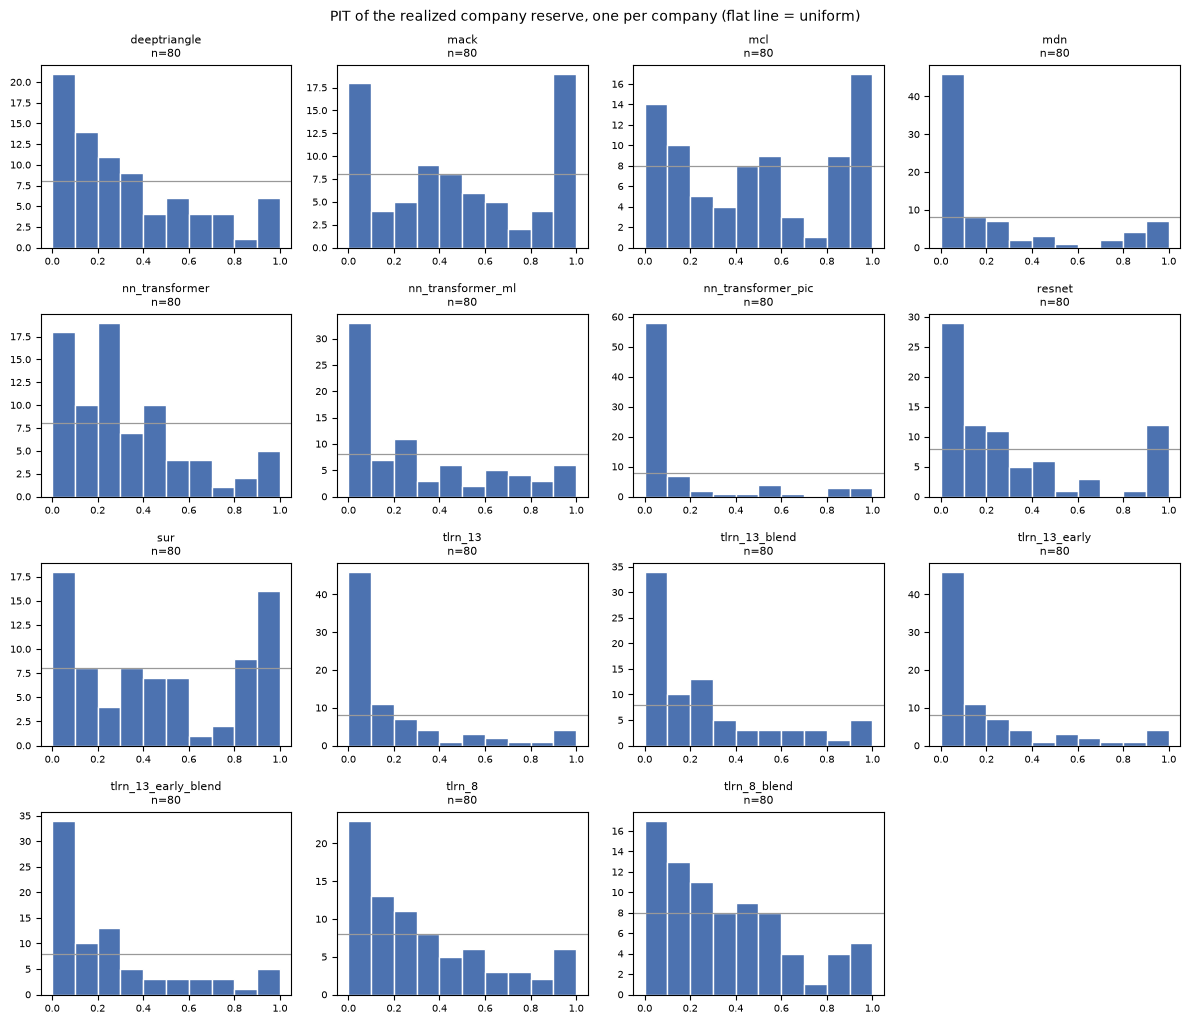

In [28]:
_models = [m for m in COMPANY_PITS if len(COMPANY_PITS[m])]
_ncol = min(4, len(_models))
_nrow = int(np.ceil(len(_models) / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(3.0 * _ncol, 2.6 * _nrow), squeeze=False)
for ax, m in zip(axes.ravel(), _models, strict=False):
    ax.hist(COMPANY_PITS[m], bins=10, range=(0, 1), color="#4c72b0", edgecolor="white")
    ax.axhline(len(COMPANY_PITS[m]) / 10, color="#999999", lw=0.9)
    ax.set_title(f"{m}\nn={len(COMPANY_PITS[m])}", fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(_models) :]:
    ax.axis("off")
fig.suptitle(
    "PIT of the realized company reserve, one per company (flat line = uniform)", fontsize=10
)
fig.tight_layout()
plt.show()

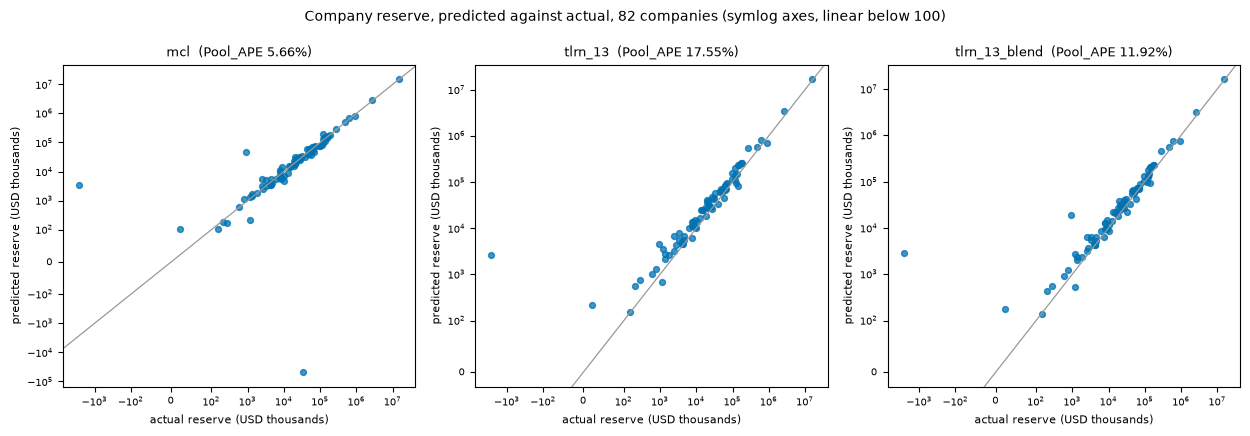

In [29]:
SCATTER_ROWS = [
    m for m in ("mcl", "tlrn_13", "tlrn_13_blend") if m in set(company_reserves["model"])
]
fig, axes = plt.subplots(
    1, len(SCATTER_ROWS), figsize=(4.2 * len(SCATTER_ROWS), 4.4), squeeze=False
)
for ax, m in zip(axes[0], SCATTER_ROWS, strict=True):
    g = board82[board82["model"] == m]
    ax.axline((0, 0), slope=1, color="#999999", lw=0.9)
    ax.scatter(g["actual_reserve"], g["predicted_reserve"], s=18, alpha=0.75, color="#0072B2")
    ax.set_xscale("symlog", linthresh=100)
    ax.set_yscale("symlog", linthresh=100)
    ax.set_xlabel("actual reserve (USD thousands)", fontsize=8)
    ax.set_ylabel("predicted reserve (USD thousands)", fontsize=8)
    ax.set_title(f"{m}  (Pool_APE {company_board.loc[m, 'pool_ape'] * 100:.2f}%)", fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle(
    f"Company reserve, predicted against actual, {len(BOARD_COMPANIES)} companies "
    "(symlog axes, linear below 100)",
    fontsize=10,
)
fig.tight_layout()
plt.show()

### Reproduction checks

Two of these are assertions and one is a finding.

`mcl` and `mack` are expected to reproduce the reference implementation's company reserves
exactly: they are the same estimator on the same cells, and the only way they can differ
is if the data or the reserve definition differ. Both are asserted below to 1e-6 relative
on all 82 companies.

`tlrn` is not expected to reproduce its digits. R torch and Python torch draw different
random streams, so ten independently seeded members select a different pair of checkpoints,
and the number moves. The protocol is what reproduces. The gap is printed and never
asserted.

In [30]:
# The reference implementation's company reserves, from the 2026-09-20 replay on data
# loaded through ibnr: (chain ladder, chain ladder + MCL), in USD thousands.
REFERENCE_RESERVES = {
    "10022": (12947.1287498661, 13872.1467006472),
    "1066": (25733.7690676254, 26834.6240822547),
    "1090": (158857.693155556, 148431.415422701),
    "11118": (46170.122235285, 46476.1595463251),
    "11126": (73242.6399044006, 70623.7326802937),
    "12866": (36856.4473356481, 35833.4277180785),
    "13439": (3315.81176658357, 3325.82499612742),
    "13501": (18925.783286707, 18538.568597467),
    "13587": (4484.83894192622, 3653.18455073427),
    "13641": (4152.38225905635, 3508.95364297461),
    "13889": (30353.9016258833, 29046.716216569),
    "13943": (6231.05032567151, 5235.5600050487),
    "14044": (8837.13371129876, 9158.88423150669),
    "14176": (43116.6757811661, 40715.1827275856),
    "14257": (25384.8336650415, 24954.5134888138),
    "14370": (1584.33830136746, 1386.47676193725),
    "14974": (54671.6100910911, 58893.7122135083),
    "15024": (56252.9586445938, 57986.8109797465),
    "15148": (253.873858772429, 108.887841296315),
    "15172": (1744.62798540698, 1828.44666274238),
    "15210": (1062.5486396349, 1111.10256718523),
    "1538": (82919.3829565912, 77762.7796189606),
    "15997": (20114.0311216006, 15144.5884135728),
    "16373": (604.26573445619, 626.095724059587),
    "16799": (2499.81590020617, 2599.77042533688),
    "1716": (21783.2291511023, 21381.7920476109),
    "17299": (243.334050391554, 175.148198495327),
    "1767": (14880291.5495871, 14933234.0161541),
    "17884": (3586.42459695934, 3414.43996529511),
    "18163": (20119.2252593943, 19366.0893633904),
    "18309": (29313.4724192237, 27518.8084219847),
    "18380": (1222.12295403876, 1295.57456987784),
    "18686": (4059.44543661438, 4182.85776319043),
    "18767": (72261.3087113685, 73620.5874213753),
    "19780": (105.171488542433, 105.786136956354),
    "2003": (3023469.41531351, 2884776.79249364),
    "20690": (26825.794806873, 28120.7333795334),
    "2135": (709300.77741246, 691519.844951234),
    "2143": (14451.6447103356, 15788.6474394153),
    "2208": (39297.5844975933, 38698.3511880807),
    "23663": (54227.4480660379, 60451.2497731128),
    "25275": (36137.140943882, 35596.3506245821),
    "26077": (70647.7898529283, 74381.4767732803),
    "26433": (86055.7834531284, 82623.075370159),
    "26797": (27836.6160832248, 30869.4729203182),
    "26808": (9720.42770862243, 5455.58763290618),
    "26905": (45029.9182444088, 50815.8879357639),
    "27022": (16210.6962092101, 16108.4442263269),
    "27065": (5903.98708246899, 6142.53930208203),
    "2712": (188972.319754805, 182788.315966601),
    "28436": (1481.47168762105, 1646.1338852709),
    "28550": (6746.28231935454, 6523.92091610771),
    "28886": (60186.2960096708, -47556.1602652569),
    "29440": (30950.4602564433, 31076.9530274914),
    "31550": (9773.39354435071, 9802.47466938528),
    "32301": (62027.065946029, 47889.6333044716),
    "3240": (169183.281267833, 169346.930798225),
    "32670": (159.383199491583, 185.465178278229),
    "34606": (5642.53073766896, 5639.94187790221),
    "353": (7929.26475998412, 11295.3286252928),
    "38466": (5225.77218866578, 5499.55663898953),
    "38733": (29882.8771576033, 31310.0547458509),
    "40568": (24952.1397135083, 23205.7636417925),
    "41300": (7043.53162409236, 6441.73671585722),
    "41459": (2798.21405094765, 3157.90521337109),
    "42439": (112029.461131904, 110671.07222276),
    "44598": (129.462933044731, 217.042192271216),
    "4839": (286257.868776179, 284525.566666218),
    "5185": (126406.213522649, 128202.987722828),
    "5320": (10345.6160746553, 14329.2749312959),
    "5690": (3682.58750600293, 3162.33577517619),
    "5940": (71405.6143646206, 71763.4487366516),
    "620": (498789.677334905, 491403.811606251),
    "6408": (5395.28393534988, 5649.27501941791),
    "6459": (3844.36906855665, 4710.21730478333),
    "671": (140683.762776789, 137725.704695626),
    "6777": (131627.198397615, 198639.9759926),
    "6947": (153835.617509571, 151845.921013425),
    "7080": (916354.370182247, 842286.525940351),
    "833": (8131.93006664866, 7247.15688675748),
    "8672": (119037.501573622, 95235.0738637039),
    "965": (57077.1226580171, 58275.9929460046),
}
assert sorted(REFERENCE_RESERVES) == sorted(BOARD_COMPANIES)

_checks = []
for model, column in (("mack", 0), ("mcl", 1)):
    g = company_reserves[
        (company_reserves["model"] == model)
        & company_reserves["company_code"].isin(BOARD_COMPANIES)
    ].set_index("company_code")
    ours = g.loc[BOARD_COMPANIES, "predicted_reserve"].to_numpy(dtype=float)
    theirs = np.array([REFERENCE_RESERVES[c][column] for c in BOARD_COMPANIES])
    relative = np.abs(ours - theirs) / np.maximum(np.abs(theirs), 1e-9)
    worst = BOARD_COMPANIES[int(np.argmax(relative))]
    _checks.append(
        {
            "row": model,
            "reference": "chain ladder" if column == 0 else "chain ladder + MCL",
            "companies": len(BOARD_COMPANIES),
            "max relative difference": float(relative.max()),
            "at company": worst,
        }
    )
display(pd.DataFrame(_checks))
for check in _checks:
    assert check["max relative difference"] < 1e-6, check
print(f"both tie-outs hold to 1e-6 relative on all {len(BOARD_COMPANIES)} companies")

# the finding: how far this notebook's transformer lands from the reference one
_gaps = []
for row, reference in (
    ("tlrn_13", "reference: raw transformer"),
    ("tlrn_13_blend", "reference: blended transformer"),
    ("mcl", "reference: chain ladder + MCL"),
    ("mack", "reference: chain ladder"),
):
    if row not in company_board.index:
        continue
    ours = float(company_board.loc[row, "pool_ape"])
    theirs = REFERENCE_POOL_APE[reference]
    _gaps.append(
        {
            "this notebook": row,
            "Pool_APE": ours,
            "reference row": reference,
            "reference Pool_APE": theirs,
            "gap (percentage points)": 100.0 * (ours - theirs),
        }
    )
print("\nthis notebook beside the reference replay (a gap is a finding, not a failure):")
display(pd.DataFrame(_gaps).round(6))

_mcl_ape = float(company_board.loc["mcl", "pool_ape"])
for row in ("tlrn_13_blend", "tlrn_8_blend", "tlrn_13_early_blend", "tlrn_13"):
    if row in company_board.index:
        ours = float(company_board.loc[row, "pool_ape"])
        print(
            f"{row:22s} Pool_APE {100 * ours:6.4f}% against mcl {100 * _mcl_ape:6.4f}%: "
            f"relative change {100 * (ours / _mcl_ape - 1):+.2f}%"
        )
print(
    f"\nthe reference replay's blended transformer improved on its chain ladder + MCL by "
    f"{100 * (1 - REFERENCE_POOL_APE['reference: blended transformer'] / REFERENCE_POOL_APE['reference: chain ladder + MCL']):.2f}%"
)

,row,reference,companies,max relative difference,at company
0,mack,chain ladder,82,7.145070e-15,1090
1,mcl,chain ladder + MCL,82,7.480755e-13,17299


both tie-outs hold to 1e-6 relative on all 82 companies

this notebook beside the reference replay (a gap is a finding, not a failure):


,this notebook,Pool_APE,reference row,reference Pool_APE,gap (percentage points)
0,tlrn_13,0.175508,reference: raw transformer,0.056256,11.925214
1,tlrn_13_blend,0.119204,reference: blended transformer,0.050880,6.832410
2,mcl,0.056606,reference: chain ladder + MCL,0.056606,0.000014
3,mack,0.057732,reference: chain ladder,0.057732,0.000023


tlrn_13_blend          Pool_APE 11.9204% against mcl 5.6606%: relative change +110.59%
tlrn_8_blend           Pool_APE 7.9724% against mcl 5.6606%: relative change +40.84%
tlrn_13_early_blend    Pool_APE 11.9204% against mcl 5.6606%: relative change +110.59%
tlrn_13                Pool_APE 17.5508% against mcl 5.6606%: relative change +210.05%

the reference replay's blended transformer improved on its chain ladder + MCL by 10.12%


### Where the error sits

A pooled Pool_APE over 82 companies of very different sizes is dominated by the largest
few. The share of each model's total absolute company error carried by each company says
how much of the headline rests on one book.

In [31]:
SHARE_ROWS = [
    m
    for m in ("mack", "mcl", "tlrn_13", "tlrn_13_blend", "nn_transformer")
    if m in set(board82["model"])
]
_shares = []
for m in SHARE_ROWS:
    g = board82[board82["model"] == m].copy()
    g["abs_error"] = (
        g["error"].abs() if "error" in g else (g["predicted_reserve"] - g["actual_reserve"]).abs()
    )
    g["share"] = g["abs_error"] / g["abs_error"].sum()
    _shares.append(g[["model", "company_code", "abs_error", "share"]])
shares = pd.concat(_shares, ignore_index=True)

_top = (
    shares.sort_values("share", ascending=False)
    .groupby("model")
    .head(5)
    .sort_values(["model", "share"], ascending=[True, False])
)
print("the five companies carrying the most absolute error, per model:")
display(_top.round(4).reset_index(drop=True))

BIGGEST = "1767" if "1767" in BOARD_COMPANIES else shares["company_code"].iloc[0]
_one = shares[shares["company_code"] == BIGGEST].set_index("model")["share"]
print(
    f"\ncompany {BIGGEST} alone carries this share of each model's total absolute "
    f"company error:\n{(100 * _one).round(1).to_string()}"
)
print(
    f"\nits premium is {PREMIUM_COMPANY[BIGGEST]:,.0f} of "
    f"{sum(PREMIUM_COMPANY[c] for c in BOARD_COMPANIES):,.0f} USD thousands on the board "
    f"({100 * PREMIUM_COMPANY[BIGGEST] / sum(PREMIUM_COMPANY[c] for c in BOARD_COMPANIES):.1f}%)"
)

the five companies carrying the most absolute error, per model:


,model,company_code,abs_error,share
0,mack,2003,3.900124e+05,0.2945
1,mack,1767,3.281475e+05,0.2478
2,mack,2135,1.046028e+05,0.0790
3,mack,32301,6.110307e+04,0.0461
4,mack,26433,2.904722e+04,0.0219
5,mcl,1767,2.752050e+05,0.2119
6,mcl,2003,2.513198e+05,0.1935
7,mcl,2135,8.682185e+04,0.0669
8,mcl,28886,8.035116e+04,0.0619
9,mcl,6777,7.710998e+04,0.0594



company 1767 alone carries this share of each model's total absolute company error:
model
mack              24.8
mcl               21.2
tlrn_13           35.7
tlrn_13_blend     31.1
nn_transformer    64.5

its premium is 170,921,305 of 242,859,443 USD thousands on the board (70.4%)


## Limitations

1. **The seeds differ from the reference framework.** R torch and Python torch draw
   different random streams, so ten independently seeded members train to different
   weights and the two that validate best are a different two. What reproduces is the
   protocol and the magnitude; the digits reproduce only for `mcl` and `mack`, which are
   deterministic.
2. **`tlrn`'s calibration residuals overlap its training targets.** The spread comes from
   applying the kept checkpoints at cutoffs 5 to 9, and at cutoffs 5 to 7 the cells being
   forecast were training targets. That is the companion study's own choice, reproduced
   here. A non-overlapping variant is one config change, `calibration_cutoffs=(8, 9)`, and
   is not run here.
3. **The blend weight is supplied, not searched.** 0.658 is the companion study's
   constant, selected there on historical origins. Nothing in this notebook tuned it, and
   nothing here should be read as evidence that it is the best weight.
4. **One valuation date.** Everything is fitted at 31 December 2007 and scored forward.
   There is no rolling-origin repetition, so a difference between two models is one draw
   from the distribution of such differences.
5. **The selection is retrospective.** A complete positive square over ten accident years
   and two qualifying lines is knowledge from the end of the window. The task is future
   development for these insurers, not generalization to unseen ones.
6. **No full run-off bootstrap comparator.** `kernels/odp_bootstrap.py` draws one diagonal,
   because that is all the one-year claims development result reads, so the
   over-dispersed Poisson bootstrap the companion study uses as its uncertainty comparator
   has no counterpart here. It would go beside the company-level distribution table.
7. **`tlrn` is scored at company level only.** Its distribution is calibrated on company
   reserves and it has no per-cell draws, so it appears in no per-cell CRPS column. It is
   not missing from that board; it has nothing to put there.
8. **The pooled neural budgets are a transfer budget, not a tuned one.** 120 epochs and
   five members is the budget the earlier notebooks used, carried over so that the neural
   rows are comparable with them. No hyperparameter search was run for this cohort set.
9. **The fits are not equal in what they see.** A pooled fit reads all 93 companies; a
   `mack` fit reads one company-line pair. The seconds in the timing table therefore do
   not compare the same unit of work, and neither does the accuracy.

In [32]:
timings = (
    pd.DataFrame(
        [
            {
                "row": k,
                "seconds": v,
                "seconds per cohort": round(
                    v / (len(PAIRS) if k in ("mack",) else len(COMPANIES)), 2
                ),
                "torch threads": TORCH_THREADS
                if k.startswith(("tlrn", "nn", "deep", "mdn", "resnet"))
                else "-",
            }
            for k, v in fit_seconds.items()
        ]
    )
    .sort_values("seconds", ascending=False)
    .reset_index(drop=True)
)
display(timings)
print(f"total fitting and forecasting: {timings['seconds'].sum() / 60:.1f} min")
print(f"notebook so far:               {(time.perf_counter() - T_START) / 60:.1f} min wall clock")

,row,seconds,seconds per cohort,torch threads
0,nn_transformer_ml,550.2,5.92,16
1,mack,374.6,1.54,-
2,nn_transformer,333.2,3.58,16
3,nn_transformer_pic,285.5,3.07,16
4,deeptriangle,275.4,2.96,16
5,mdn,252.2,2.71,16
6,resnet,214.0,2.30,16
7,tlrn_13,158.7,1.71,16
8,tlrn_8,141.1,1.52,16
9,sur,138.1,1.48,-


total fitting and forecasting: 49.9 min
notebook so far:               58.1 min wall clock


In [33]:
import torch  # noqa: F811  (re-imported so this cell stands alone if run on its own)

HEADLINE = {
    row: float(company_board.loc[row, "pool_ape"])
    for row in company_board.index
    if not row.startswith("reference")
}
manifest = {
    "protocol": PROTOCOL,
    "ibnr": ibnr.__version__,
    "cas_schedule_p": cas_schedule_p.__version__,
    "publish_id": PUBLISH_ID,
    "as_of": AS_OF.isoformat(),
    "origins": [o.isoformat() for o in ORIGINS],
    "loss_field": FIELD,
    "cohort_set_hash": COHORT_HASH,
    "board_hash": BOARD_HASH,
    "companies": len(COMPANIES),
    "pairs": len(PAIRS),
    "board_companies": len(BOARD_COMPANIES),
    "held_out_cells": int(N_HELDOUT),
    "crps_cell_set_hash": aligned.crps_fingerprint,
    "crps_cells": int(aligned.n_cells_for("crps")),
    "seed_fit": SEED_FIT,
    "seed_draw": SEED_DRAW,
    "blend_weight": BLEND_WEIGHT,
    "budgets": BUDGETS[PROTOCOL],
    "fit_seconds": fit_seconds,
    "torch_threads": TORCH_THREADS,
    "company_pool_ape": HEADLINE,
    "reference_pool_ape": REFERENCE_POOL_APE,
    "wall_clock_minutes": round((time.perf_counter() - T_START) / 60, 2),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "torch": torch.__version__,
}
(OUT / "run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
company_board.to_csv(OUT / "company_board.csv")
company_reserves.to_csv(OUT / "company_reserves.csv", index=False)
pair_board.to_csv(OUT / "pair_board.csv")
next_board.to_csv(OUT / "next_diagonal_board.csv", index=False)
print(json.dumps(manifest, indent=2))
print(f"\nwritten to {OUT}")
if PROTOCOL == "smoke":
    print("\nSMOKE RUN - none of the scores above may be quoted.")

{
  "protocol": "smoke",
  "ibnr": "0.7.0",
  "cas_schedule_p": "2026.6.13",
  "publish_id": "20260613_041006",
  "as_of": "2007-12-31",
  "origins": [
    "1998-01-01",
    "1999-01-01",
    "2000-01-01",
    "2001-01-01",
    "2002-01-01",
    "2003-01-01",
    "2004-01-01",
    "2005-01-01",
    "2006-01-01",
    "2007-01-01"
  ],
  "loss_field": "paid_loss",
  "cohort_set_hash": "08605b3c80513bca",
  "board_hash": "b0654c51cf80ac0e",
  "companies": 93,
  "pairs": 243,
  "board_companies": 82,
  "held_out_cells": 2187,
  "crps_cell_set_hash": "2f84696277cec0d5",
  "crps_cells": 2070,
  "seed_fit": 11,
  "seed_draw": 7,
  "blend_weight": 0.658,
  "budgets": {
    "nn": {
      "max_epochs": 3,
      "patience": 15,
      "ensemble_size": 2,
      "n_draws": 50,
      "val_diagonals": 2,
      "min_cutoff": 2
    },
    "tlrn": {
      "ensemble_size": 2,
      "keep": 1,
      "max_epochs": 30,
      "min_epochs": 0,
      "check_every": 5,
      "patience": 100,
      "n_draws": 500